In [2]:
from innolux import *


In [11]:
root = data_path / Path("T2 6628 BP 3500 A ZIX-7061 S-NP13 S-WB141")

for i,j,k in os.walk(root):
    print(i,j,k)

D:\Documents\Projects\innolux\data\T2 6628 BP 3500 A ZIX-7061 S-NP13 S-WB141 [] ['around_gap_condition_20250731.xlsx', 'around_gap_diff_rms_d0.png', 'around_gap_diff_rms_d2.png', 'around_gap_summary_20250903.xlsx']


## LCDP

In [2]:
LiquidCrystal.data.loc['ZIX-7061XX',:]

Vender               JNC
measure temp.         25
Tni(℃)              76.1
Tcn(℃)               -30
d                    3.3
Δnd                0.344
ne                1.5879
no                1.4838
Δn                0.1041
ε∥                   3.4
ε⊥                   6.6
Δε                  -3.2
ν                   11.8
γ1                  78.0
K11                 15.3
K22                  7.7
K33                 15.3
K33/K11              1.0
density          1.00388
Name: ZIX-7061XX, dtype: object

In [2]:
lc_amount_calc('LCT-15-1098', 3.2, '6628')

31.203000000000003

In [3]:
lc_amount_calc('ZIX-7061XX', 3.2, '6628')


31.51314651911469

In [6]:
LiquidCrystal.data.loc['ZIX-7061XX', :]

Vender               JNC
measure temp.         25
Tni(℃)              76.1
Tcn(℃)               -30
d                    3.3
Δnd                0.344
ne                1.5879
no                1.4838
Δn                0.1041
ε∥                   3.4
ε⊥                   6.6
Δε                  -3.2
ν                   11.8
γ1                  78.0
K11                 15.3
K22                  7.7
K33                 15.3
K33/K11              1.0
density          1.00388
Name: ZIX-7061XX, dtype: object

## EDC & Q-Time

In [12]:
[asm_edc, asm_qtime, id_map, _] = pl.read_excel(
    root / "660L ASM Qtime+TFT對應CF ID+Gap.xlsx", 
    sheet_id=0,
).values()
# asm_qtime = pl.read_excel(
#     root / "660L ASM Qtime+TFT對應CF ID+Gap.xlsx", 
#     sheet_id=2,
# )
# id_map = pl.read_excel(
#     root / "660L ASM Qtime+TFT對應CF ID+Gap.xlsx", 
#     sheet_id=3,
# )

Could not determine dtype for column 19, falling back to string


In [13]:
id_map

ARRAY_GLASS_ID,CF_GLASS_ID,BATCH_ID,Condition
str,str,str,str
"""660L2AP50FN209""","""660L2FP43B7T22""","""EF255233""","""ZIX-7061XX + S-NP13"""
"""660L2AP50FN210""","""660L2FP43ATT46""","""EF255226""","""LCT-15-1098 + S-WB141"""
"""660L2AP50FN211""","""660L2FP43BKT45""","""EF255232""","""ZIX-7061XX + S-WB141"""
"""660L2AP50FN212""","""660L2FP43BFT15""","""EF255232""","""ZIX-7061XX + S-WB141"""
"""660L2AP50FN213""","""660L2FP43BXT13""","""EF255233""","""ZIX-7061XX + S-NP13"""
"""660L2AP50FN214""","""660L2FP43BTT16""","""EF255233""","""ZIX-7061XX + S-NP13"""
"""660L2AP50FN215""","""660L2FP43BUT54""","""EF255232""","""ZIX-7061XX + S-WB141"""


In [213]:
edc_df = pl.read_csv(root / 'edc_20250618.csv')
glass_trace_df = pl.read_csv(root / 'glass_trace_history_20250617.csv')

### EDC

In [214]:
edc_df

STEP_ID,GLASS_ID,PROCESS_START_TIME,PROCESS_END_TIME,COMPONENT_ID,COMPONENT_TYPE,EQUIP_ID,SUB_EQUIP_ID,PRODUCT_ID,BATCH_ID,LOT_ID,ARRAY_LOT_ID,ARRAY_GLASS_ID,CF_GLASS_ID,RECIPE_ID,TA_ID,CASSETTE_ID,PROCESS_MODE,PLAN_ID,FAB_AREA,BATCH_TYPE,ABNORMAL_FLAG,PANEL_SIZE,MODEL_NAME,SLOT_ID,PARAM_COLLECTION,PARAM_NAME,PARAM_VALUE,AVG,STD,MAX,MIN,COUNT,PARAM_STR_VALUE,RN
str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,str,str,str,str,str,str,i64
"""6220_PH2_PA_UV""","""660L2FP43ATT46""","""5/23/2025 07:18""","""5/23/2025 07:24""","""660L2FP43ATT46""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43ATT""",""" ""","""660L2FP43ATT46""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",60,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",214.0,""" """,""" """,""" """,""" """,""" """,""" """,1
"""6220_PH2_PA_UV""","""660L2FP43B7T22""","""5/23/2025 07:18""","""5/23/2025 07:23""","""660L2FP43B7T22""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43B7T""",""" ""","""660L2FP43B7T22""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",58,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",212.0,""" """,""" """,""" """,""" """,""" """,""" """,2
"""6220_PH2_PA_UV""","""660L2FP43BFT15""","""5/23/2025 07:18""","""5/23/2025 07:25""","""660L2FP43BFT15""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43BFT""",""" ""","""660L2FP43BFT15""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",62,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",213.0,""" """,""" """,""" """,""" """,""" """,""" """,3
"""6220_PH2_PA_UV""","""660L2FP43BKT45""","""5/23/2025 07:18""","""5/23/2025 07:26""","""660L2FP43BKT45""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43BKT""",""" ""","""660L2FP43BKT45""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",64,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",213.0,""" """,""" """,""" """,""" """,""" """,""" """,4
"""6220_PH2_PA_UV""","""660L2FP43BTT16""","""5/23/2025 07:18""","""5/23/2025 07:25""","""660L2FP43BTT16""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43BTT""",""" ""","""660L2FP43BTT16""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",61,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",216.0,""" """,""" """,""" """,""" """,""" """,""" """,5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""6220_PH3_OVEN""","""660L2AP50FN215""","""5/23/2025 05:42""","""5/23/2025 05:53""","""660L2AP50FN215""",1,"""2CPHA300""","""2CPHA350""","""660L2C""","""EF255226""","""660L2YP50FN2.01""","""660L2AP50FN2""","""660L2AP50FN215""",""" ""","""660L_T01""","""BC""","""2C345""","""IPS""","""IPSPHA1""","""T2""","""E""",""" ""","""6.6W""","""F066A28-6T1""",60,"""PDSG_2CPHA300_2CPHA350""","""Baking temp zone5""",229.9,""" """,""" """,""" """,""" """,""" """,""" """,996
"""6220_PH3_OVEN""","""660L2AP50FN215""","""5/23/2025 05:42""","""5/23/2025 05:53""","""660L2AP50FN215""",1,"""2CPHA300""","""2CPHA350""","""660L2C""","""EF255226""","""660L2YP50FN2.01""","""660L2AP50FN2""","""660L2AP50FN215""",""" ""","""660L_T01""","""BC""","""2C345""","""IPS""","""IPSPHA1""","""T2""","""E""",""" ""","""6.6W""","""F066A28-6T1""",60,"""PDSG_2CPHA300_2CPHA350""","""Baking temp zone6""",230.0,""" """,""" """,""" """,""" """,""" """,""" """,997
"""6220_PH3_OVEN""","""660L2AP50FN215""","""5/23/2025 05:42""","""5/23/2025 05:53""","""660L2AP50FN215""",1,"""2CPHA300""","""2CPHA350""","""660L2C""","""EF255226"

In [213]:
(edc_df
    .filter(
        pl.col('GLASS_ID').str.contains('2FP'),
        pl.col('SUB_EQUIP_ID').str.contains('PI')
    )    
    .select('GLASS_ID','SUB_EQUIP_ID', 'ARRAY_GLASS_ID')
    .unique()
)

GLASS_ID,SUB_EQUIP_ID,ARRAY_GLASS_ID
str,str,str
"""660L2FP43BKT45""","""2CPIL680""",""" """
"""660L2FP43BUT54""","""2CPIL670""",""" """
"""660L2FP43ATT46""","""2CPIL680""",""" """
"""660L2FP43BTT16""","""2CPIL680""",""" """
"""660L2FP43ATT46""","""2CPIL670""",""" """
…,…,…
"""660L2FP43B7T22""","""2CPIL670""",""" """
"""660L2FP43BXT13""","""2CPIL680""",""" """
"""660L2FP43BKT45""","""2CPIL670""",""" """


In [350]:
id_map.select(
    'Condition',
    pl.col('ARRAY_GLASS_ID').alias('TFT'),
    pl.col('CF_GLASS_ID').alias('CF'),
)

Condition,TFT,CF
str,str,str
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22"""
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46"""
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45"""
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15"""
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13"""
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16"""
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54"""


In [356]:
id_map.select(
    'Condition',
    pl.col('ARRAY_GLASS_ID').alias('TFT'),
    pl.col('CF_GLASS_ID').alias('CF'),
).join(
    (
        edc_df
        .select(
            "GLASS_ID",
            'STEP_ID',
            'SUB_EQUIP_ID',
            'PROCESS_START_TIME',
            'PROCESS_END_TIME',
            'PARAM_NAME',
            'PARAM_VALUE',
        )
        .filter(
            pl.col('STEP_ID').str.starts_with('6110'),
            pl.col('GLASS_ID').str.contains("660L2A"),
            pl.col('PARAM_NAME').str.contains("(?i)temp"),
            pl.col('PARAM_VALUE').is_between(130, 140),
        )
        .group_by('GLASS_ID').agg(pl.col('PARAM_VALUE').mean().alias('PIPR TEMP - T'))
    ).join(
        edc_df
        .select(
            "GLASS_ID",
            'STEP_ID',
            'SUB_EQUIP_ID',
            'PROCESS_START_TIME',
            'PROCESS_END_TIME',
            'PARAM_NAME',
            'PARAM_VALUE',
        )
        .filter(
            pl.col('STEP_ID').str.starts_with('6110'),
            pl.col('GLASS_ID').str.contains("660L2A"),
            pl.col('PARAM_NAME').str.contains("(?i)prctime"),
        )
        .group_by('GLASS_ID').agg(pl.col('PARAM_VALUE').mean().alias('PIPR TIME - T')),
        on='GLASS_ID'
    ),
    left_on='TFT',
    right_on='GLASS_ID',
    how='left'
).join(
    (
        edc_df
        .select(
            "GLASS_ID",
            'STEP_ID',
            'SUB_EQUIP_ID',
            'PROCESS_START_TIME',
            'PROCESS_END_TIME',
            'PARAM_NAME',
            'PARAM_VALUE',
        )
        .filter(
            pl.col('STEP_ID').str.starts_with('6110'),
            pl.col('GLASS_ID').str.contains("660L2F"),
            pl.col('PARAM_NAME').str.contains("(?i)temp"),
            pl.col('PARAM_VALUE').is_between(130, 140),
        )
        .group_by('GLASS_ID').agg(pl.col('PARAM_VALUE').mean().alias('PIPR TEMP - C'))
    ).join(
        edc_df
        .select(
            "GLASS_ID",
            'STEP_ID',
            'SUB_EQUIP_ID',
            'PROCESS_START_TIME',
            'PROCESS_END_TIME',
            'PARAM_NAME',
            'PARAM_VALUE',
        )
        .filter(
            pl.col('STEP_ID').str.starts_with('6110'),
            pl.col('GLASS_ID').str.contains("660L2F"),
            pl.col('PARAM_NAME').str.contains("(?i)prctime"),
        )
        .group_by('GLASS_ID').agg(pl.col('PARAM_VALUE').mean().alias('PIPR TIME - C')),
        on='GLASS_ID'
    ),
    left_on='CF',
    right_on='GLASS_ID',
    how='left'
)

Condition,TFT,CF,PIPR TEMP - T,PIPR TIME - T,PIPR TEMP - C,PIPR TIME - C
str,str,str,f64,f64,f64,f64
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",null,null,134.5,80.0
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",null,null,134.75,80.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",null,null,135.0,80.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",null,null,135.0,80.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",null,null,134.75,80.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",null,null,135.0,80.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",null,null,134.75,80.0


In [216]:
cond_df = id_map.select(
    'Condition',
    pl.col('ARRAY_GLASS_ID').alias('TFT'),
    pl.col('CF_GLASS_ID').alias('CF'),
).sort(['Condition', 'TFT'])

In [217]:
def edc_stack_helper(df, col_name: str, cond_df=cond_df):
    t_df = df.filter(pl.col('GLASS_ID').str.starts_with('660L2A')).group_by('GLASS_ID').agg(pl.col('PARAM_VALUE').mean().alias(f'{col_name} - T'))
    c_df = df.filter(pl.col('GLASS_ID').str.starts_with('660L2F')).group_by('GLASS_ID').agg(pl.col('PARAM_VALUE').mean().alias(f'{col_name} - C'))

    return cond_df.join(
        t_df, left_on='TFT', right_on='GLASS_ID', how='left',
    ).join(
        c_df, left_on='CF', right_on='GLASS_ID', how='left',
    )
    
def edc_stack_helper_odf(df, col_name: str, cond_df=cond_df):
    t_df = df.filter(pl.col('GLASS_ID').str.starts_with('660L2A')).group_by('GLASS_ID').agg(pl.col('PARAM_VALUE').mean().alias(f'{col_name}'))

    return cond_df.join(
        t_df, left_on='TFT', right_on='GLASS_ID', how='left',
    )

In [42]:
pipr_df = edc_stack_helper(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6110'),
        pl.col('PARAM_NAME').str.contains("(?i)temp"),
        pl.col('PARAM_VALUE').is_between(130, 140),
    ),
    'PIPR TEMP'
).join(edc_stack_helper(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6110'),
        pl.col('PARAM_NAME').str.contains("(?i)prctime"),
    ),
    'PIPR TIME'
), on=['Condition', 'TFT', 'CF'])
pipr_df

Condition,TFT,CF,PIPR TEMP - T,PIPR TEMP - C,PIPR TIME - T,PIPR TIME - C
str,str,str,f64,f64,f64,f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",135.0,134.75,null,80.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",135.0,134.5,null,80.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",135.0,134.75,null,80.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",135.0,135.0,null,80.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",135.0,135.0,null,80.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",135.0,135.0,null,80.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",135.0,134.75,null,80.0


In [470]:
(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'SUB_EQUIP_ID',
        'PROCESS_START_TIME',
        'PROCESS_END_TIME',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6110'),
        pl.col('PARAM_NAME').str.contains("Heating_Time"),
        # pl.col('PARAM_VALUE').is_between(600,800),
    )
).select('SUB_EQUIP_ID').unique()

SUB_EQUIP_ID
str
"""2CPIL4A0"""
"""2CPIL6C0"""


In [43]:
pipb_df = edc_stack_helper(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6110'),
        pl.col('PARAM_NAME').str.contains("Hot_Plate_Temp"),
    ),
    'PIPB TEMP'
).join(edc_stack_helper(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6110'),
        pl.col('PARAM_NAME').str.contains("Heating_Time"),
    ),
    'PIPB TIME'
), on=['Condition', 'TFT', 'CF'])
pipb_df

Condition,TFT,CF,PIPB TEMP - T,PIPB TEMP - C,PIPB TIME - T,PIPB TIME - C
str,str,str,f64,f64,f64,f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",210.5,209.9,611.0,608.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",211.5,209.4,613.0,612.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",211.1,209.8,608.0,608.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",211.0,209.7,616.0,608.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",210.8,209.3,608.0,646.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",212.9,209.5,616.0,624.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",213.0,209.1,626.0,646.0


In [452]:
(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'SUB_EQUIP_ID',
        'PROCESS_START_TIME',
        'PROCESS_END_TIME',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6220'),
        pl.col('PARAM_NAME').str.contains(r"\d-\d exp"),
        pl.col('PARAM_VALUE') > 0,
    )
)

GLASS_ID,STEP_ID,SUB_EQUIP_ID,PROCESS_START_TIME,PROCESS_END_TIME,PARAM_NAME,PARAM_VALUE
str,str,str,str,str,str,f64
"""660L2FP43ATT46""","""6220_PH2_PA_UV""","""2CPHA240""","""2025/05/23 07:18:53""","""2025/05/23 07:24:29""","""1-1 exposure""",254.0
"""660L2FP43B7T22""","""6220_PH2_PA_UV""","""2CPHA240""","""2025/05/23 07:18:53""","""2025/05/23 07:23:26""","""1-1 exposure""",254.0
"""660L2FP43BFT15""","""6220_PH2_PA_UV""","""2CPHA240""","""2025/05/23 07:18:53""","""2025/05/23 07:25:37""","""1-1 exposure""",254.0
"""660L2FP43BKT45""","""6220_PH2_PA_UV""","""2CPHA240""","""2025/05/23 07:18:53""","""2025/05/23 07:26:39""","""1-1 exposure""",255.0
"""660L2AP50FN211""","""6220_PH3_PA_UV""","""2CPHA340""","""2025/05/23 05:42:17""","""2025/05/23 05:51:46""","""1-1 exposure""",268.0
…,…,…,…,…,…,…
"""660L2FP43BXT13""","""6220_PH2_PA_UV""","""2CPHA240""","""2025/05/23 07:18:53""","""2025/05/23 07:23:56""","""2-3 exposure""",247.0
"""660L2AP50FN209""","""6220_PH3_PA_UV""","""2CPHA340""","""2025/05/23 05:42:17""","""2025/05/23 05:58:58""","""2-3 exposure""",272.0
"""660L2AP50FN210""","""6220_PH3_PA_UV""","""2CPHA340""","""2025/05/23 05:42:17""","""2025/05/23 05:46:27""","""2-3 exposure""",272.0


In [44]:
pauv_df = edc_stack_helper(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6220'),
        pl.col('PARAM_NAME').str.contains(r"\d-\d exp"),
        pl.col('PARAM_VALUE') > 0,
    ),
    'PAUV'
)
pauv_df

Condition,TFT,CF,PAUV - T,PAUV - C
str,str,str,f64,f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",261.333333,247.666667
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",261.333333,247.666667
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",261.333333,247.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",261.666667,247.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",261.333333,248.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",261.333333,247.666667
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",261.333333,247.0


In [454]:
(edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'SUB_EQUIP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6220'),
        pl.col('PARAM_NAME').str.contains("Heating_Time"),
    )).select('SUB_EQUIP_ID').unique()

SUB_EQUIP_ID
str
"""2CPHA350"""
"""2CPHA250"""


In [54]:
edc_df.head(10)

STEP_ID,GLASS_ID,PROCESS_START_TIME,PROCESS_END_TIME,COMPONENT_ID,COMPONENT_TYPE,EQUIP_ID,SUB_EQUIP_ID,PRODUCT_ID,BATCH_ID,LOT_ID,ARRAY_LOT_ID,ARRAY_GLASS_ID,CF_GLASS_ID,RECIPE_ID,TA_ID,CASSETTE_ID,PROCESS_MODE,PLAN_ID,FAB_AREA,BATCH_TYPE,ABNORMAL_FLAG,PANEL_SIZE,MODEL_NAME,SLOT_ID,PARAM_COLLECTION,PARAM_NAME,PARAM_VALUE,AVG,STD,MAX,MIN,COUNT,PARAM_STR_VALUE,RN
str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,str,str,str,str,str,str,i64
"""6220_PH2_PA_UV""","""660L2FP43ATT46""","""5/23/2025 07:18""","""5/23/2025 07:24""","""660L2FP43ATT46""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43ATT""",""" ""","""660L2FP43ATT46""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",60,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",214.0,""" """,""" """,""" """,""" """,""" """,""" """,1
"""6220_PH2_PA_UV""","""660L2FP43B7T22""","""5/23/2025 07:18""","""5/23/2025 07:23""","""660L2FP43B7T22""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43B7T""",""" ""","""660L2FP43B7T22""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",58,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",212.0,""" """,""" """,""" """,""" """,""" """,""" """,2
"""6220_PH2_PA_UV""","""660L2FP43BFT15""","""5/23/2025 07:18""","""5/23/2025 07:25""","""660L2FP43BFT15""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43BFT""",""" ""","""660L2FP43BFT15""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",62,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",213.0,""" """,""" """,""" """,""" """,""" """,""" """,3
"""6220_PH2_PA_UV""","""660L2FP43BKT45""","""5/23/2025 07:18""","""5/23/2025 07:26""","""660L2FP43BKT45""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43BKT""",""" ""","""660L2FP43BKT45""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",64,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",213.0,""" """,""" """,""" """,""" """,""" """,""" """,4
"""6220_PH2_PA_UV""","""660L2FP43BTT16""","""5/23/2025 07:18""","""5/23/2025 07:25""","""660L2FP43BTT16""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43BTT""",""" ""","""660L2FP43BTT16""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",61,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",216.0,""" """,""" """,""" """,""" """,""" """,""" """,5
"""6220_PH2_PA_UV""","""660L2FP43BUT54""","""5/23/2025 07:18""","""5/23/2025 07:26""","""660L2FP43BUT54""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43BUT""",""" ""","""660L2FP43BUT54""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",63,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",214.0,""" """,""" """,""" """,""" """,""" """,""" """,6
"""6220_PH2_PA_UV""","""660L2FP43BXT13""","""5/23/2025 07:18""","""5/23/2025 07:23""","""660L2FP43BXT13""",4,"""2CPHA200""","""2CPHA240""","""660L2F""","""PF251121""","""660L2TP43BCT.02""","""660L2FP43BXT""",""" ""","""660L2FP43BXT13""","""660L_F01""","""BC""","""2W117""","""IPS""","""IPSCFPHA1""","""T2""","""P""",""" ""","""6.6W""","""F066A28-6T1""",59,"""PDSG_2CPHA200_2CPHA240""","""1 HEAP differential""",212.0,""" """,""" """,""" """,""" """,""" """,""" """,7
"""6220_PH3_PA_UV""","""660L2AP50FN209""","""5/23/2025 05:42""","""5/23/2025 05:58""","""660L2AP50FN209""",1,"""2CPHA300""","""2CPHA340""","""660L2C""","""EF255226""","""660L2YP50FN2.01""","""660L2AP50FN2""","""660L2AP50FN209""

In [48]:
papb_df = edc_stack_helper(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6220'),
        pl.col('PARAM_NAME').str.contains("Hot_Plate_Temp|Baking temp"),
    ),
    'PAPB TEMP'
).join(edc_stack_helper(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6220'),
        pl.col('PARAM_NAME').str.contains("Heating_Time"),
    ),
    'PAPB TIME'
), on=['Condition', 'TFT', 'CF'])
papb_df

Condition,TFT,CF,PAPB TEMP - T,PAPB TEMP - C,PAPB TIME - T,PAPB TIME - C
str,str,str,f64,f64,f64,f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",230.21,230.0,1813.0,1809.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",230.36,229.9,1801.0,1810.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",230.15,230.2,1801.0,1810.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",230.34,230.0,1801.0,1809.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",230.02,229.4,1801.0,1808.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",230.06,229.7,1802.0,1809.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",230.24,230.2,1802.0,1809.0


In [455]:
(edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'SUB_EQUIP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        # pl.col('STEP_ID').str.starts_with('6310'),
        pl.col('STEP_ID').str.contains('ARO'),
        pl.col('PARAM_NAME').str.contains("Heating_Time"),
        # pl.col('PARAM_VALUE').is_between(140, 160)
    )
    .select('SUB_EQUIP_ID').unique()
)

SUB_EQUIP_ID
str
"""2CASM130"""


In [49]:
boox_df = edc_stack_helper_odf(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6310'),
        pl.col('PARAM_NAME').str.contains("(?i)temp"),
        pl.col('PARAM_VALUE').is_between(140, 160)
    ),
    'BOOX TEMP'
).join(edc_stack_helper_odf(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.contains('ARO'),
        pl.col('PARAM_NAME').str.contains("Heating_Time"),
    ),
    'BOOX TIME'
), on=['Condition', 'TFT', 'CF'])
boox_df

Condition,TFT,CF,BOOX TEMP,BOOX TIME
str,str,str,f64,f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",151.15,604.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",151.3,605.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",151.275,604.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",151.3,604.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",151.0,604.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",151.2,604.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",151.125,604.0


In [456]:
(edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'SUB_EQUIP_ID',
        'PARAM_NAME',
        pl.col('PARAM_VALUE') * 10,
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6310'),
        pl.col('PARAM_NAME').str.contains("(?i)energy"),
        # pl.col('PARAM_VALUE') > 0,
    )).select('SUB_EQUIP_ID').unique()

SUB_EQUIP_ID
str
"""2CASM1C0"""


In [50]:
seuv_df = edc_stack_helper_odf(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        pl.col('PARAM_VALUE') * 10,
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6310'),
        pl.col('PARAM_NAME').str.contains("(?i)energy"),
    ),
    'SEUV'
)
seuv_df

Condition,TFT,CF,SEUV
str,str,str,f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",6000.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",6000.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",6000.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",6000.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",6000.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",6000.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",6000.0


In [234]:
odf_to_seuv = edc_stack_helper_odf(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        pl.col('PARAM_VALUE'),
    )
    .filter(
        pl.col('STEP_ID').str.starts_with('6310'),
        pl.col('PARAM_NAME').str.contains("ODF_UV_QTime"),
    ),
    'ODF to SEUV(sec)'
)
odf_to_seuv

Condition,TFT,CF,ODF to SEUV(sec)
str,str,str,f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",68.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",67.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",78.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",72.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",68.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",72.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",69.0


In [475]:
(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'SUB_EQUIP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.contains('SMO'),
        pl.col('PARAM_NAME').str.contains("Heating_Time"),
        # pl.col('PARAM_VALUE').is_between(140, 160)
    )
)

GLASS_ID,STEP_ID,SUB_EQUIP_ID,PARAM_NAME,PARAM_VALUE
str,str,str,str,f64
"""660L2AP50FN209""","""6310_AS1_SMO""","""2CASM1D0""","""Heating_Time""",3649.0
"""660L2AP50FN210""","""6310_AS1_SMO""","""2CASM1D0""","""Heating_Time""",3647.0
"""660L2AP50FN211""","""6310_AS1_SMO""","""2CASM1D0""","""Heating_Time""",3648.0
"""660L2AP50FN212""","""6310_AS1_SMO""","""2CASM1D0""","""Heating_Time""",3647.0
"""660L2AP50FN213""","""6310_AS1_SMO""","""2CASM1D0""","""Heating_Time""",3647.0
"""660L2AP50FN214""","""6310_AS1_SMO""","""2CASM1D0""","""Heating_Time""",3648.0
"""660L2AP50FN215""","""6310_AS1_SMO""","""2CASM1D0""","""Heating_Time""",3648.0


In [51]:
sepb_df = edc_stack_helper_odf(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.contains('SMO'),
        pl.col('PARAM_NAME').str.contains("(?i)temp"),
    ),
    'SEPB TEMP'
).join(edc_stack_helper_odf(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        pl.col('STEP_ID').str.contains('SMO'),
        pl.col('PARAM_NAME').str.contains("Heating_Time"),
    ),
    'SEPB TIME'
), on=['Condition', 'TFT', 'CF'])
sepb_df

Condition,TFT,CF,SEPB TEMP,SEPB TIME
str,str,str,f64,f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",119.98,3647.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",120.0,3649.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",119.94,3647.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",120.0,3648.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",119.98,3648.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",119.98,3647.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",120.0,3648.0


In [52]:
(pipr_df
    .join(pipb_df,['Condition','TFT','CF'])
    .join(pauv_df,['Condition','TFT','CF'])
    .join(papb_df,['Condition','TFT','CF'])
    .join(boox_df,['Condition','TFT','CF'])
    .join(seuv_df,['Condition','TFT','CF'])
    .join(sepb_df,['Condition','TFT','CF'])
).write_excel(root / 'edc_summary.xlsx')

In [425]:
(
    edc_df
    .select(
        "GLASS_ID",
        'STEP_ID',
        'SUB_EQUIP_ID',
        'PROCESS_START_TIME',
        'PROCESS_END_TIME',
        'PARAM_NAME',
        'PARAM_VALUE',
    )
    .filter(
        # pl.col('STEP_ID').str.starts_with('6110'),
        # pl.col('GLASS_ID') == "660L2FP43BKT45",
        # pl.col('GLASS_ID').str.contains("L2A"),
        # pl.col('SUB_EQUIP_ID').str.contains("2CPIL[1-9]A"),
        pl.col('PARAM_NAME').str.contains("time"),
        pl.col('PARAM_VALUE').is_between(60, 100),
    )
    # .unique("STEP_ID").sort("STEP_ID")
    # .group_by('GLASS_ID').agg(pl.col('PARAM_VALUE').mean().alias('PIPR TEMP'))
)

GLASS_ID,STEP_ID,SUB_EQUIP_ID,PROCESS_START_TIME,PROCESS_END_TIME,PARAM_NAME,PARAM_VALUE
str,str,str,str,str,str,f64


### Q-Time

In [426]:
edc_df.columns

['STEP_ID',
 'GLASS_ID',
 'PROCESS_START_TIME',
 'PROCESS_END_TIME',
 'COMPONENT_ID',
 'COMPONENT_TYPE',
 'EQUIP_ID',
 'SUB_EQUIP_ID',
 'PRODUCT_ID',
 'BATCH_ID',
 'LOT_ID',
 'ARRAY_LOT_ID',
 'ARRAY_GLASS_ID',
 'CF_GLASS_ID',
 'RECIPE_ID',
 'TA_ID',
 'CASSETTE_ID',
 'PROCESS_MODE',
 'PLAN_ID',
 'FAB_AREA',
 'BATCH_TYPE',
 'ABNORMAL_FLAG',
 'PANEL_SIZE',
 'MODEL_NAME',
 'SLOT_ID',
 'PARAM_COLLECTION',
 'PARAM_NAME',
 'PARAM_VALUE',
 'AVG',
 'STD',
 'MAX',
 'MIN',
 'COUNT',
 'PARAM_STR_VALUE',
 'RN',
 '']

In [218]:
glass_trace_df.head()

LINE,MOTHEREQUIPMENTID,EQUIPMENTID,STARTDATETIME,ENDDATETIME,SEQUENCE,LOTID,GLASSID,PRODUCTID,STEPID,PPID,PROCESSTIME,ENDTACTTIME,LOTTYPE,SEMISTATE,STIGNORE,PROCESSGROUP,NEW_PROCESSGROUP
str,str,str,str,str,i64,str,str,str,str,str,i64,i64,str,str,str,str,str
"""T2CELL""","""2CPIL600""","""2CPIL610""","""5/23/2025 00:06""","""5/23/2025 00:07""",1,"""660L2FP43BCT.14""","""660L2FP43BUT54""","""660L2F""","""6110_PI""","""660L_F01""",52,38,"""CG""","""ERUN""","""S""",null,null
"""T2CELL""","""2CPIL600""","""2CPIL610""","""5/23/2025 00:07""","""5/23/2025 00:08""",1,"""660L2FP43BCT.14""","""660L2FP43BKT45""","""660L2F""","""6110_PI""","""660L_F01""",51,38,"""CG""","""ERUN""","""S""",null,null
"""T2CELL""","""2CPIL600""","""2CPIL610""","""5/23/2025 00:08""","""5/23/2025 00:10""",1,"""660L2FP43BCT.14""","""660L2FP43BFT15""","""660L2F""","""6110_PI""","""660L_F01""",124,110,"""CG""","""ERUN""","""S""",null,null
"""T2CELL""","""2CPIL600""","""2CPIL610""","""5/23/2025 00:11""","""5/23/2025 00:12""",1,"""660L2FP43BCT.14""","""660L2FP43BTT16""","""660L2F""","""6110_PI""","""660L_F01""",52,38,"""CG""","""ERUN""","""S""",null,null
"""T2CELL""","""2CPIL600""","""2CPIL610""","""5/23/2025 00:12""","""5/23/2025 00:13""",1,"""660L2FP43BCT.14""","""660L2FP43ATT46""","""660L2F""","""6110_PI""","""660L_F01""",52,38,"""CG""","""ERUN""","""S""",null,null


In [219]:
q_time_raw = glass_trace_df.select(
     pl.col('GLASSID').alias('GLASS_ID'),
     pl.col('STEPID').alias('STEP_ID'),
     pl.col('EQUIPMENTID').alias('EQUIPMENT_ID'),
     pl.col('STARTDATETIME').str.to_datetime('%m/%d/%Y %H:%M').alias('Input Time'),
     pl.col('ENDDATETIME').str.to_datetime('%m/%d/%Y %H:%M').alias('Output Time'),
     
)

In [220]:
(q_time_raw
    .filter(
        # pl.col('GLASS_ID') == '660L2AP50FN211',
        # pl.col('EQUIPMENT_ID').str.contains(r'CPIL\dA0|2CPIL6C0'), # PIPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d40'), # PAUV
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d50'), # PAPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dC0'), # BOOX
        pl.col('EQUIPMENT_ID').str.contains(r'CASM\dD0'), # SEUV
    )
    # .sort('Input')
    # .group_by('GLASS_ID', maintain_order=True).last()
)

GLASS_ID,STEP_ID,EQUIPMENT_ID,Input Time,Output Time
str,str,str,datetime[μs],datetime[μs]
"""660L2AP50FN211""","""6310_ASM""","""2CASM1D0""",2025-05-23 14:26:00,2025-05-23 15:32:00
"""660L2AP50FN212""","""6310_ASM""","""2CASM1D0""",2025-05-23 18:01:00,2025-05-23 19:08:00
"""660L2AP50FN215""","""6310_ASM""","""2CASM1D0""",2025-05-23 18:11:00,2025-05-23 19:17:00
"""660L2AP50FN210""","""6310_ASM""","""2CASM1D0""",2025-05-23 19:12:00,2025-05-23 20:19:00
"""660L2AP50FN214""","""6310_ASM""","""2CASM1D0""",2025-05-23 22:46:00,2025-05-23 23:53:00
"""660L2AP50FN213""","""6310_ASM""","""2CASM1D0""",2025-05-23 22:48:00,2025-05-23 23:55:00
"""660L2AP50FN209""","""6310_ASM""","""2CASM1D0""",2025-05-23 22:55:00,2025-05-24 00:01:00


In [222]:
def qtime_stack_helper(df, col_name: str, cond_df=cond_df):
    t_df = df.filter(pl.col('GLASS_ID').str.starts_with('660L2A')).group_by('GLASS_ID').agg(pl.col('Input Time').mean().alias('Input Time - T'))
    c_df = df.filter(pl.col('GLASS_ID').str.starts_with('660L2F')).group_by('GLASS_ID').agg(pl.col('Input Time').mean().alias('Input Time - C'))

    return cond_df.join(
        t_df, left_on='TFT', right_on='GLASS_ID', how='left',
    ).join(
        c_df, left_on='CF', right_on='GLASS_ID', how='left',
    )
    
def qtime_stack_helper_odf(df, col_name: str, cond_df=cond_df):
    t_df = df.filter(pl.col('GLASS_ID').str.starts_with('660L2A')).group_by('GLASS_ID').agg(pl.col('Input Time').mean())

    return cond_df.join(
        t_df, left_on='TFT', right_on='GLASS_ID', how='left',
    )
    
def qtime_calc(
    df1, process_name_1,
    df2, process_name_2,
):
    len_1 = df1.select(pl.selectors.matches('Input Time')).shape[1]
    len_2 = df2.select(pl.selectors.matches('Input Time')).shape[1]

    if len_1 == 2 and len_2 == 2:
        return df1[:,:3].with_columns(
            (df2['Input Time - T'] - df1['Input Time - T']).alias(f'{process_name_1} to {process_name_2} - T'),
            (df2['Input Time - C'] - df1['Input Time - C']).alias(f'{process_name_1} to {process_name_2} - C'),
        )
    elif len_1 == 2 and len_2 == 1:
        return df1[:,:3].with_columns(
            (df2['Input Time'] - df1['Input Time - T']).alias(f'{process_name_1} to {process_name_2} - T'),
            (df2['Input Time'] - df1['Input Time - C']).alias(f'{process_name_1} to {process_name_2} - C'),
        )
    else:
        return df1[:,:3].with_columns(
            (df2['Input Time'] - df1['Input Time']).alias(f'{process_name_1} to {process_name_2}'),
        )

In [223]:
pipb_time = qtime_stack_helper(q_time_raw
    .filter(
        pl.col('EQUIPMENT_ID').str.contains(r'CPIL\dA0|2CPIL6C0'), # PIPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d40'), # PAUV
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d50'), # PAPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dC0'), # BOOX
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dD0'), # SEUV
    ), 'PIPB')

In [224]:
pauv_time = qtime_stack_helper(q_time_raw
    .filter(
        # pl.col('EQUIPMENT_ID').str.contains(r'CPIL\dA0|2CPIL6C0'), # PIPB
        pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d40'), # PAUV
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d50'), # PAPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dC0'), # BOOX
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dD0'), # SEUV
    ), 'PAUV')

In [225]:
papb_time = qtime_stack_helper(q_time_raw
    .filter(
        # pl.col('EQUIPMENT_ID').str.contains(r'CPIL\dA0|2CPIL6C0'), # PIPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d40'), # PAUV
        pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d50'), # PAPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dC0'), # BOOX
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dD0'), # SEUV
    ), 'PAPB')

In [226]:
boox_time = qtime_stack_helper_odf(q_time_raw
    .filter(
        # pl.col('EQUIPMENT_ID').str.contains(r'CPIL\dA0|2CPIL6C0'), # PIPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d40'), # PAUV
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d50'), # PAPB
        pl.col('EQUIPMENT_ID').str.contains(r'CASM120'), # BOOX
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dD0'), # SEUV
 ), 'BOOX')

In [227]:
odfx_time = qtime_stack_helper_odf(q_time_raw
    .filter(pl.col('EQUIPMENT_ID').str.contains(r'CASM1C0'), # BOOX
), 'ODFX')

In [228]:
seuv_time = qtime_stack_helper_odf(q_time_raw
    .filter(
        # pl.col('EQUIPMENT_ID').str.contains(r'CPIL\dA0|2CPIL6C0'), # PIPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d40'), # PAUV
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d50'), # PAPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dC0'), # BOOX
        pl.col('EQUIPMENT_ID').str.contains(r'CASM\dD0'), # SEUV
    ), 'SEUV')

In [233]:
(q_time_raw
    .filter(
        # pl.col('EQUIPMENT_ID').str.contains(r'CPIL\dA0|2CPIL6C0'), # PIPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d40'), # PAUV
        # pl.col('EQUIPMENT_ID').str.contains(r'CPHA\d50'), # PAPB
        # pl.col('EQUIPMENT_ID').str.contains(r'CASM\dC0'), # BOOX
        pl.col('EQUIPMENT_ID').str.contains(r'CASM'), # SEUV
        pl.col('GLASS_ID')=='660L2AP50FN210',
    )
)

GLASS_ID,STEP_ID,EQUIPMENT_ID,Input Time,Output Time
str,str,str,datetime[μs],datetime[μs]
"""660L2AP50FN210""","""6310_ASM""","""2CASM110""",2025-05-23 18:21:00,2025-05-23 18:22:00
"""660L2AP50FN210""","""6310_ASM""","""2CASM120""",2025-05-23 18:22:00,2025-05-23 18:26:00
"""660L2AP50FN210""","""6310_ASM""","""2CASM131""",2025-05-23 18:26:00,2025-05-23 18:36:00
"""660L2AP50FN210""","""6310_ASM""","""2CASM130""",2025-05-23 18:36:00,2025-05-23 18:42:00
"""660L2AP50FN210""","""6310_ASM""","""2CASM132""",2025-05-23 18:36:00,2025-05-23 18:42:00
…,…,…,…,…
"""660L2AP50FN210""","""6310_ASM""","""2CASM1E2""",2025-05-23 20:19:00,2025-05-23 20:24:00
"""660L2AP50FN210""","""6310_ASM""","""2CASM1E1""",2025-05-23 20:25:00,2025-05-23 20:28:00
"""660L2AP50FN210""","""6310_ASM""","""2CASM1E0""",2025-05-23 20:19:00,2025-05-23 20:28:00


In [229]:
qtime_calc(
    boox_time, 'BOOX',
    odfx_time, 'ODFX',
)

Condition,TFT,CF,BOOX to ODFX
str,str,str,duration[μs]
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",46m
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",1h 12m
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",1h 9m
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",1h 8m
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",54m
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",46m
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",53m


In [230]:
qtime_calc(
    odfx_time, 'ODFX',
    seuv_time, 'SEUV',
)

Condition,TFT,CF,ODFX to SEUV
str,str,str,duration[μs]
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",4m
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",6m
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",4m
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",4m
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",5m
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",4m
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",5m


In [498]:
pipb_time

Condition,TFT,CF,Input Time - T,Input Time - C
str,str,str,datetime[μs],datetime[μs]
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",2025-05-23 01:58:00,2025-05-23 06:22:00
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",2025-05-23 01:53:00,2025-05-23 06:24:00
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",2025-05-23 01:55:00,2025-05-23 06:23:00
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",2025-05-23 01:57:00,2025-05-23 06:21:00
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",2025-05-23 01:54:00,2025-05-23 06:17:00
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",2025-05-23 01:57:00,2025-05-23 06:18:00
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",2025-05-23 01:55:00,2025-05-23 06:17:00


In [238]:
qtime_calc(
    pipb_time, 'PIPB',
    pauv_time, 'PAUV',
).join(
    qtime_calc(
        pauv_time, 'PAUV',
        papb_time, 'PAPB',
    ),
    on=['Condition', 'TFT', 'CF']
).join(
    qtime_calc(
        papb_time, 'PAPB',
        boox_time, 'BOOX',
    ),
    on=['Condition', 'TFT', 'CF']
).join(
    qtime_calc(
        boox_time, 'BOOX',
        odfx_time, 'ODFX',
    ),
    on=['Condition', 'TFT', 'CF']
).join(
    odf_to_seuv,
    on=['Condition', 'TFT', 'CF']
).write_excel(root / 'qtime_summary.xlsx')
# ).join( # 好像有問題
#     qtime_calc(
#         boox_time, 'BOOX',
#         seuv_time, 'SEUV',
#     ),
#     on=['Condition', 'TFT', 'CF']
# )

In [236]:
odf_to_seuv

Condition,TFT,CF,ODF to SEUV(sec)
str,str,str,f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",68.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",67.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",78.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",72.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",68.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",72.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",69.0


In [237]:
qtime_calc(
    pipb_time, 'PIPB',
    pauv_time, 'PAUV',
).join(
    qtime_calc(
        pauv_time, 'PAUV',
        papb_time, 'PAPB',
    ),
    on=['Condition', 'TFT', 'CF']
).join(
    qtime_calc(
        papb_time, 'PAPB',
        boox_time, 'BOOX',
    ),
    on=['Condition', 'TFT', 'CF']
).join(
    qtime_calc(
        boox_time, 'BOOX',
        odfx_time, 'ODFX',
    ),
    on=['Condition', 'TFT', 'CF']
).join(
    odf_to_seuv,
    on=['Condition', 'TFT', 'CF']
)

Condition,TFT,CF,PIPB to PAUV - T,PIPB to PAUV - C,PAUV to PAPB - T,PAUV to PAPB - C,PAPB to BOOX - T,PAPB to BOOX - C,BOOX to ODFX,ODF to SEUV(sec)
str,str,str,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],f64
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210""","""660L2FP43ATT46""",3h 48m,1h 2m,3m,3m,12h 33m,10h 55m,46m,68.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""660L2FP43B7T22""",4h 5m,59m,3m,3m,15h 36m,14h 11m,1h 12m,67.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213""","""660L2FP43BXT13""",4h 4m,1h,2m,3m,15h 34m,14h 9m,1h 9m,78.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""660L2FP43BTT16""",4h 3m,1h 4m,3m,2m,15h 31m,14h 7m,1h 8m,72.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211""","""660L2FP43BKT45""",3h 57m,1h 9m,4m,3m,7h 32m,5h 58m,54m,68.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212""","""660L2FP43BFT15""",3h 53m,1h 7m,3m,3m,11h 18m,9h 43m,46m,72.0
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215""","""660L2FP43BUT54""",3h 56m,1h 9m,2m,2m,11h 20m,9h 45m,53m,69.0


## CGM

In [18]:
cgm = pl.read_excel(
    root / "660L ASM Qtime+TFT對應CF ID+Gap.xlsx", 
    sheet_id=4,
)

Could not determine dtype for column 19, falling back to string


In [19]:
cgm

STEP_ID,GLASS_ID,MEASURE_START_TIME,PARAM_COLLECTION,PARAM_NAME,SITE_NAME,No.,ID,PARAM_VALUE,MEASURE_END_TIME,COMPONENT_ID,COMPONENT_TYPE,PRODUCT_ID,BATCH_ID,LOT_ID,EQUIP_ID,ARRAY_LOT_ID,ARRAY_GLASS_ID,CF_GLASS_ID,SUB_EQUIP_ID,RECIPE_ID,PROCESS_PLAN,TA_ID,TA_SHIFT,CST_ID,LOT_TYPE,SLOT_ID,BATCH_TYPE,PANEL_SIZE,MODEL_NAME,PROCESS_MODE,ABNORMAL_FLAG,RECIPE_NO,X,Y,SPEC_HIGH,SPEC_LOW,SPEC_TARGET,RN,RN_1
str,str,datetime[ms],str,str,str,str,str,f64,datetime[ms],str,i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,i64,str,str,str,str,str,i64,f64,f64,str,str,str,i64,i64
"""6320_CG1_CGM""","""660L2AP50FN211""",2025-05-23 14:10:10,"""660L_02""","""CELLGAP""","""CHIP_10_1_CELLGAP""","""A42""","""660L2AP50FN211A42""",3.15,2025-05-23 14:25:55,"""660L2AP50FN211""",1,"""660L2C""","""EF255232""","""660L2YP50FN2.05""","""2CCGM100""","""660L2AP50FN2""","""660L2AP50FN211""","""660L2FP43BKT45""","""NA""","""660L_02""","""IPSPHA1_B""",144,""" ""","""2E83""","""E""",50,"""E""","""6.6W""","""F066A28-6T1""","""IPS""",""" """,901,-410.74,213.475,"""3.35""","""3.05""",""" """,1,1
"""6320_CG1_CGM""","""660L2AP50FN211""",2025-05-23 14:10:10,"""660L_02""","""CELLGAP""","""CHIP_10_2_CELLGAP""","""A42""","""660L2AP50FN211A42""",3.172,2025-05-23 14:25:55,"""660L2AP50FN211""",1,"""660L2C""","""EF255232""","""660L2YP50FN2.05""","""2CCGM100""","""660L2AP50FN2""","""660L2AP50FN211""","""660L2FP43BKT45""","""NA""","""660L_02""","""IPSPHA1_B""",144,""" ""","""2E83""","""E""",50,"""E""","""6.6W""","""F066A28-6T1""","""IPS""",""" """,901,-410.74,110.517,"""3.35""","""3.05""",""" """,2,2
"""6320_CG1_CGM""","""660L2AP50FN211""",2025-05-23 14:10:10,"""660L_02""","""CELLGAP""","""CHIP_11_1_CELLGAP""","""AA2""","""660L2AP50FN211AA2""",3.186,2025-05-23 14:25:55,"""660L2AP50FN211""",1,"""660L2C""","""EF255232""","""660L2YP50FN2.05""","""2CCGM100""","""660L2AP50FN2""","""660L2AP50FN211""","""660L2FP43BKT45""","""NA""","""660L_02""","""IPSPHA1_B""",144,""" ""","""2E83""","""E""",50,"""E""","""6.6W""","""F066A28-6T1""","""IPS""",""" """,901,-410.74,513.475,"""3.35""","""3.05""",""" """,3,3
"""6320_CG1_CGM""","""660L2AP50FN211""",2025-05-23 14:10:10,"""660L_02""","""CELLGAP""","""CHIP_11_2_CELLGAP""","""AA2""","""660L2AP50FN211AA2""",3.182,2025-05-23 14:25:55,"""660L2AP50FN211""",1,"""660L2C""","""EF255232""","""660L2YP50FN2.05""","""2CCGM100""","""660L2AP50FN2""","""660L2AP50FN211""","""660L2FP43BKT45""","""NA""","""660L_02""","""IPSPHA1_B""",144,""" ""","""2E83""","""E""",50,"""E""","""6.6W""","""F066A28-6T1""","""IPS""",""" """,901,-410.74,410.517,"""3.35""","""3.05""",""" """,4,4
"""6320_CG1_CGM""","""660L2AP50FN211""",2025-05-23 14:10:10,"""660L_02""","""CELLGAP""","""CHIP_12_1_CELLGAP""","""EH2""","""660L2AP50FN211EH2""",3.188,2025-05-23 14:25:55,"""660L2AP50FN211""",1,"""660L2C""","""EF255232""","""660L2YP50FN2.05""","""2CCGM100""","""660L2AP50FN2""","""660L2AP50FN211""","""660L2FP43BKT45""","""NA""","""660L_02""","""IPSPHA1_B""",144,""" ""","""2E83""","""E""",50,"""E""","""6.6W""","""F066A28-6T1""","""IPS""",""" """,901,-410.74,813.475,"""3.35""","""3.05""",""" """,5,5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""6320_CG1_CGM""","""660L2AP50FN209""",2025-05-24 01:46:20,"""660L_02""","""TWIST""","""CHIP_80_1_TWIST""","""HBB""","""660L2AP50FN209HBB""",0.077,2025-05-24 02:02:26,"""660L2AP50FN209""",1,"""660L2C""","""EF255233""","""660L2YP50FN2.01""","""2CCGM100""","""660L2AP50FN2""","""660L2AP50FN209""","""660L2FP43B7T22""","""NA""","""660L_02""","""IPSPHA1_B""",144,""" ""","""2E72""","""E""",48,"""E""","""6.6W""","""F066A28-6T1""","""IPS""",""" """,528,37.728,879.515,"""1.3""","""-0.7""",""" """,3452,null
"""6320_CG1_CGM""","""660L2AP50FN209""",2025-05-24 01:46:20,"""660L_02""","""TWIST""","""CHIP_81_1_TWIST""","""HHB""","""660L2AP50FN209HHB""",-0.658,2025-05-24 02:02:26,"""660L2AP50FN209""",1,"""660L2C""","""EF255233""","""660L2YP50FN2.01""","""2CCGM100""","""660L2AP50FN2""","""660L2AP50FN209""","""660L2FP43B7T22""","""NA

## 斷面積

In [14]:
seal_cross_raw = pl.read_excel(root / "660L_新膠材_斷面積.xlsx")
seal_head_map_raw = pl.read_excel( data_path / "global" / "product_infos.xlsx", sheet_name="seal_head_map")
sub_map_raw = pl.read_excel(data_path / "global" / "product_infos.xlsx", sheet_name="sub_map")

In [23]:
seal_cross_df = (seal_cross_raw
    .filter(pl.col("PARAM_NAME").is_in(param_name_mask))
    .select(
        pl.col("GLASS_ID").alias('CF_GLASS_ID'), 
        pl.col("EQUIP_ID").str.slice(2,6).alias('Line'),
        pl.col("PARAM_NAME").str.slice(9, length=2).alias("Head"), 
        pl.col("PARAM_VALUE").cast(pl.Int32).alias('Cross Area'),)
    .filter(pl.col("Cross Area") != 0)
    .join(id_map, on='CF_GLASS_ID')
).select(
    pl.col('ARRAY_GLASS_ID').alias('Sub ID'),
    'Head',
    'Condition',
    'Cross Area'
)

In [34]:
chip_seal_cross_summary = (
    id_map
    .select(pl.col('ARRAY_GLASS_ID').alias('Sub ID'))
    .join(sub_map,how='cross')
).join(
    seal_head_map_raw
    .filter(pl.col('PFCD') == '6628', pl.col('Equipment') == 'ASM100')
    .select('Panel ID', 'Head'),
    on='Panel ID'
).join(
    seal_cross_df,
    on=['Sub ID', 'Head']
).select(
    'Condition',
    (pl.col('Sub ID') + pl.col('CUT') + pl.col('Panel ID')).alias('Panel ID'),
    'Cross Area'
).with_columns(
    pl.col('Panel ID').map_elements(lambda chip_id: chip_location(chip_id, '6628'), return_dtype=str).alias('Location')
)


In [36]:
chip_seal_cross_summary.write_excel(root / 'chip_seal_cross_summary.xlsx')

In [266]:
chip_seal_cross_summary

Condition,Panel ID,Cross Area,Location
str,str,i32,str
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209A11""",2525,"""Outer"""
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209A21""",2525,"""Outer"""
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209A31""",2525,"""Outer"""
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209A41""",2525,"""Outer"""
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209A51""",2525,"""Outer"""
…,…,…,…
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215HGB""",2345,"""Outer"""
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215HHB""",2345,"""Outer"""
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215HJB""",2345,"""Outer"""


In [28]:
seal_cross_df.select('Sub ID').unique()

Sub ID
str
"""660L2AP50FN211"""
"""660L2AP50FN214"""
"""660L2AP50FN215"""
"""660L2AP50FN212"""
"""660L2AP50FN209"""
"""660L2AP50FN210"""


In [27]:
id_map

ARRAY_GLASS_ID,CF_GLASS_ID,BATCH_ID,Condition
str,str,str,str
"""660L2AP50FN209""","""660L2FP43B7T22""","""EF255233""","""ZIX-7061XX + S-NP13"""
"""660L2AP50FN210""","""660L2FP43ATT46""","""EF255226""","""LCT-15-1098 + S-WB141"""
"""660L2AP50FN211""","""660L2FP43BKT45""","""EF255232""","""ZIX-7061XX + S-WB141"""
"""660L2AP50FN212""","""660L2FP43BFT15""","""EF255232""","""ZIX-7061XX + S-WB141"""
"""660L2AP50FN213""","""660L2FP43BXT13""","""EF255233""","""ZIX-7061XX + S-NP13"""
"""660L2AP50FN214""","""660L2FP43BTT16""","""EF255233""","""ZIX-7061XX + S-NP13"""
"""660L2AP50FN215""","""660L2FP43BUT54""","""EF255232""","""ZIX-7061XX + S-WB141"""


In [6]:
sub_map = sub_map_raw.filter(
    pl.col('PFCD') == 6628,
).select("Panel ID", "CUT")

In [7]:
seal_head_map = seal_head_map_raw.filter(
    pl.col("PFCD") == '6628',
    pl.col("Equipment") == 'ASM100',
).select(
    'Panel ID',
    'Head'
).join(
    sub_map,
    on='Panel ID'
).select(
    'Head',
    'CUT'
).unique([
    "Head", "CUT"
]).sort(by='Head').group_by("Head").agg(pl.col("CUT"))
seal_head_map

Head,CUT
str,list[str]
"""L3""","[""D""]"
"""L4""","[""D""]"
"""L5""","[""C""]"
"""L6""","[""B"", ""C""]"
"""L7""","[""B""]"
…,…
"""R4""","[""H""]"
"""R5""","[""G""]"
"""R6""","[""F"", ""G""]"


In [8]:
param_name_mask = [
    "Seal AreaL3P1",
    "Seal AreaL4P1",
    "Seal AreaL5P1",
    "Seal AreaL6P1",
    "Seal AreaL7P1",
    "Seal AreaL8P1",
    "Seal AreaR3P1",
    "Seal AreaR4P1",
    "Seal AreaR5P1",
    "Seal AreaR6P1",
    "Seal AreaR7P1",
    "Seal AreaR8P1",
]

In [101]:
seal_cross_df = (seal_cross_raw
    .filter(pl.col("PARAM_NAME").is_in(param_name_mask))
    .select(
        pl.col("GLASS_ID").alias('CF_GLASS_ID'), 
        pl.col("EQUIP_ID").str.slice(2,6).alias('Line'),
        pl.col("PARAM_NAME").str.slice(9, length=2).alias("Head"), 
        pl.col("PARAM_VALUE").cast(pl.Int32).alias('Cross Area'),)
    .filter(pl.col("Cross Area") != 0)
    .join(id_map, on='CF_GLASS_ID')
    .join(seal_head_map, on='Head',)
    .with_columns(
        pl.col('CUT').map_elements(
            lambda lst: ", ".join([str(i) for i in lst]),
            return_dtype=str,
        ).alias('Cuts'),)
    .sort(["BATCH_ID",'Cuts'])
)
seal_cross_df

CF_GLASS_ID,Line,Head,Cross Area,ARRAY_GLASS_ID,BATCH_ID,Condition,CUT,Cuts
str,str,str,i32,str,str,str,list[str],str
"""660L2FP43ATT46""","""ASM100""","""L8""",2323,"""660L2AP50FN210""","""EF255226""","""LCT-15-1098 + S-WB141""","[""A""]","""A"""
"""660L2FP43ATT46""","""ASM100""","""L7""",2328,"""660L2AP50FN210""","""EF255226""","""LCT-15-1098 + S-WB141""","[""B""]","""B"""
"""660L2FP43ATT46""","""ASM100""","""L6""",2501,"""660L2AP50FN210""","""EF255226""","""LCT-15-1098 + S-WB141""","[""B"", ""C""]","""B, C"""
"""660L2FP43ATT46""","""ASM100""","""L5""",2537,"""660L2AP50FN210""","""EF255226""","""LCT-15-1098 + S-WB141""","[""C""]","""C"""
"""660L2FP43ATT46""","""ASM100""","""L3""",2323,"""660L2AP50FN210""","""EF255226""","""LCT-15-1098 + S-WB141""","[""D""]","""D"""
…,…,…,…,…,…,…,…,…
"""660L2FP43B7T22""","""ASM100""","""R6""",2527,"""660L2AP50FN209""","""EF255233""","""ZIX-7061XX + S-NP13""","[""G"", ""F""]","""G, F"""
"""660L2FP43B7T22""","""ASM100""","""R3""",2518,"""660L2AP50FN209""","""EF255233""","""ZIX-7061XX + S-NP13""","[""H""]","""H"""
"""660L2FP43BTT16""","""ASM100""","""R4""",2370,"""660L2AP50FN214""","""EF255233""","""ZIX-7061XX + S-NP13""","[""H""]","""H"""


In [9]:
(seal_cross_raw
    .filter(pl.col("PARAM_NAME").is_in(param_name_mask))
    .select(
        pl.col("GLASS_ID").alias('CF_GLASS_ID'), 
        pl.col("EQUIP_ID").str.slice(2,6).alias('Line'),
        pl.col("PARAM_NAME").str.slice(9, length=2).alias("Head"), 
        pl.col("PARAM_VALUE").cast(pl.Int32).alias('Cross Area'),)
    .filter(pl.col("Cross Area") != 0)
)

CF_GLASS_ID,Line,Head,Cross Area
str,str,str,i32
"""660L2FP43ATT46""","""ASM100""","""L3""",2323
"""660L2FP43ATT46""","""ASM100""","""L4""",2538
"""660L2FP43ATT46""","""ASM100""","""L5""",2537
"""660L2FP43ATT46""","""ASM100""","""L6""",2501
"""660L2FP43ATT46""","""ASM100""","""L7""",2328
…,…,…,…
"""660L2FP43BUT54""","""ASM100""","""R4""",2291
"""660L2FP43BUT54""","""ASM100""","""R5""",2334
"""660L2FP43BUT54""","""ASM100""","""R6""",2429


In [185]:
(seal_cross_df
    .filter(
        # pl.col("Cross Area").is_between(2450, 2550) |
        # pl.col("Cross Area").is_between(2350, 2450) |
        pl.col("Cross Area").is_between(2300, 2500),
        # pl.col("Condition") == 'LCT-15-1098 + S-WB141',
        # pl.col("Condition") == 'ZIX-7061XX + S-WB141',
        pl.col("Condition") == 'ZIX-7061XX + S-NP13',
    )
    .group_by(['Condition','ARRAY_GLASS_ID', 'Cuts'])
    .mean()
    .select(['Condition', 'ARRAY_GLASS_ID', 'Cuts', 'Cross Area'])
)

Condition,ARRAY_GLASS_ID,Cuts,Cross Area
str,str,str,f64
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""E""",2498.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""H""",2370.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""A""",2459.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""B, C""",2417.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214""","""B""",2446.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""B""",2456.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""B, C""",2449.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""D""",2425.0
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209""","""F""",2447.0


In [152]:
root

WindowsPath('../assets/T2_SWB141_換膠驗証/6628_先行確認批/1_FEOL')

In [250]:
(seal_cross_df
    .filter(
        # pl.col("Cross Area").is_between(2450, 2550) |
        # pl.col("Cross Area").is_between(2350, 2450),
        pl.col("Cross Area").is_between(2250, 2450),
        # pl.col("Condition") == 'LCT-15-1098 + S-WB141',
        # pl.col("Condition") == 'ZIX-7061XX + S-WB141',
        pl.col("Condition") == 'ZIX-7061XX + S-NP13',
    )
    .select(['Condition', 'Head','ARRAY_GLASS_ID', 'Cuts', 'Cross Area'])
    .filter(
        (
            pl.col("Condition").eq('LCT-15-1098 + S-WB141') &
            pl.col('Cuts').str.contains('B|D|G|F')
        ) | (
            pl.col("Condition").eq('ZIX-7061XX + S-WB141') &
            pl.col('Cuts').str.contains('B|C|D|H|G|F')
        ) | (
            pl.col("Condition").eq('ZIX-7061XX + S-NP13') &
            pl.col('Cuts').str.contains('B|C|D|H|G|F')
        )
    )
    .sort(['ARRAY_GLASS_ID', 'Cuts'])
    # .filter(pl.col('ARRAY_GLASS_ID') == '660L2AP50FN212')
)

Condition,Head,ARRAY_GLASS_ID,Cuts,Cross Area
str,str,str,str,i32
"""ZIX-7061XX + S-NP13""","""L6""","""660L2AP50FN209""","""B, C""",2449
"""ZIX-7061XX + S-NP13""","""L4""","""660L2AP50FN209""","""D""",2378
"""ZIX-7061XX + S-NP13""","""R7""","""660L2AP50FN209""","""F""",2447
"""ZIX-7061XX + S-NP13""","""R4""","""660L2AP50FN209""","""H""",2272
"""ZIX-7061XX + S-NP13""","""L7""","""660L2AP50FN214""","""B""",2446
"""ZIX-7061XX + S-NP13""","""L6""","""660L2AP50FN214""","""B, C""",2417
"""ZIX-7061XX + S-NP13""","""R4""","""660L2AP50FN214""","""H""",2370


In [270]:
sample_cuts_compare = (seal_cross_df
    .select(
        "Condition",
        pl.col("ARRAY_GLASS_ID").alias("SUB ID"),
        pl.col("CUT"),
        "Cross Area"
    )
    .explode("CUT")
    .with_columns((pl.col("SUB ID") + pl.col("CUT")).alias('CUT ID'))
    .with_columns(
        pl.col("CUT ID").is_in([
            "660L2AP50FN210B",
            "660L2AP50FN210D",
            "660L2AP50FN210F",
            "660L2AP50FN210G",
            "660L2AP50FN212B",
            "660L2AP50FN212C",
            "660L2AP50FN212D",
            "660L2AP50FN212F",
            "660L2AP50FN212H",
            "660L2AP50FN215B",
            "660L2AP50FN215C",
            "660L2AP50FN209B",
            "660L2AP50FN209C",
            "660L2AP50FN209D",
            "660L2AP50FN209F",
            "660L2AP50FN209H",
            "660L2AP50FN214B",
            "660L2AP50FN214C",
        ]).alias("Sample")
    )
)

In [265]:
sample_cuts_compare

NameError: name 'sample_cuts_compare' is not defined

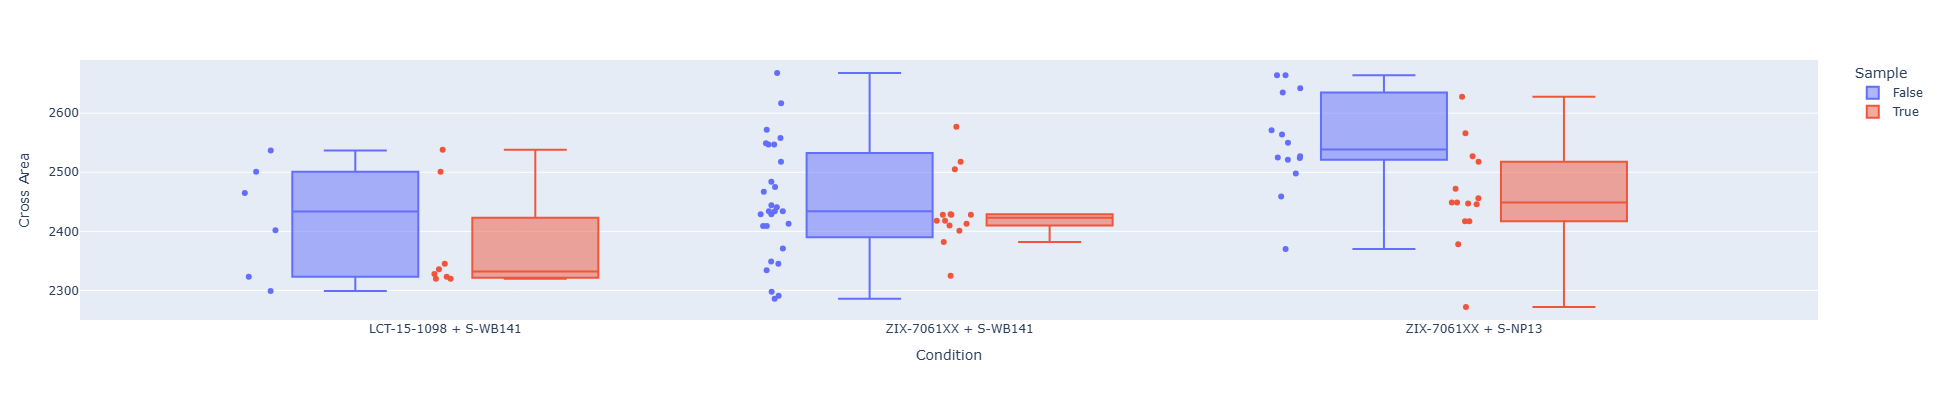

In [281]:
fig = px.box(
    sample_cuts_compare,
    x='Condition',
    y='Cross Area',
    color='Sample',
    points="all"
)
fig.update_layout(width=800,height=400)
# fig.update_layout(scattermode="group", scattergap=0.75)
fig.show()

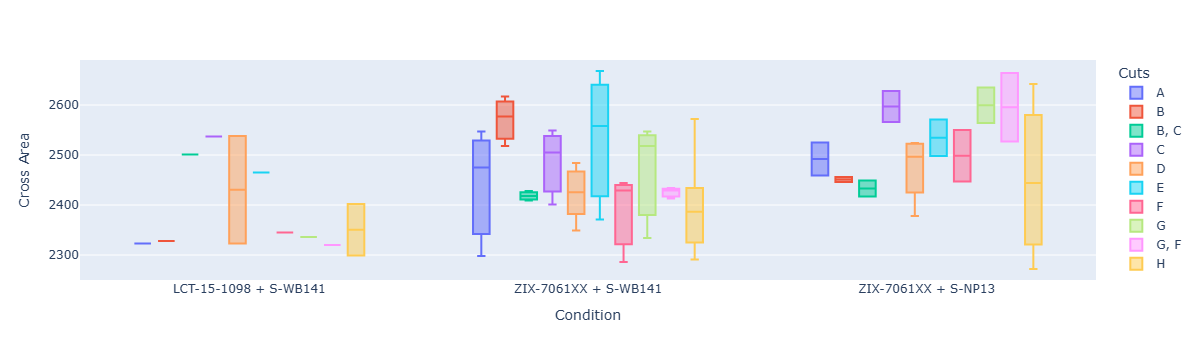

In [102]:
fig = px.box(
    seal_cross_df,
    x='Condition',
    y='Cross Area',
    color='Cuts',
)
fig.show()

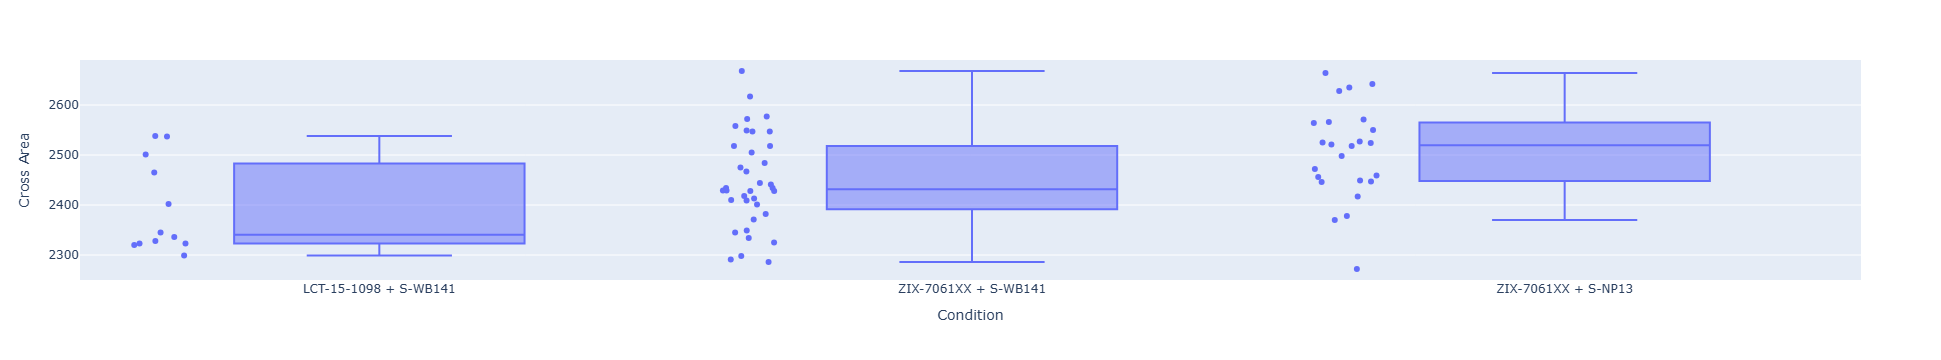

In [148]:
fig = px.box(
    seal_cross_df,
    x='Condition',
    y='Cross Area',
    # color='Cuts',
    points='all',
)
fig.show()

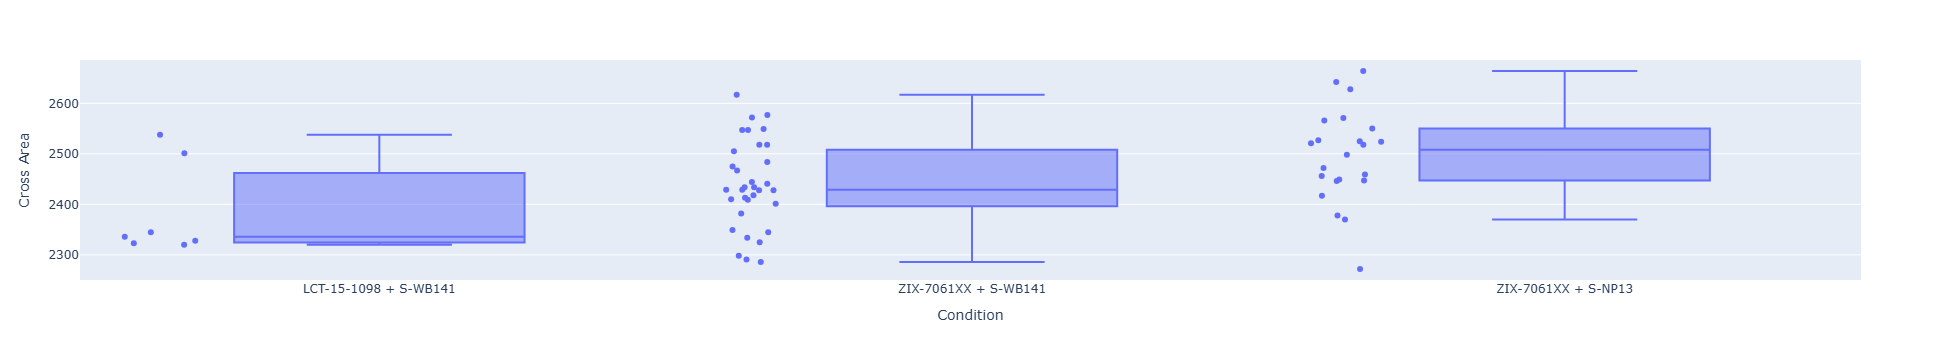

In [149]:
fig = px.box(
    cuts_selected,
    x='Condition',
    y='Cross Area',
    # color='Cuts',
    points='all',
)
fig.show()

In [92]:
seal_cross_df['CUT'].map_elements(
    lambda lst: ", ".join([str(i) for i in lst]),
    return_dtype=str,
).to_list()

['D',
 'D',
 'C',
 'B, C',
 'B',
 'A',
 'H',
 'H',
 'G',
 'G, F',
 'F',
 'E',
 'D',
 'D',
 'C',
 'B, C',
 'B',
 'A',
 'H',
 'H',
 'G',
 'G, F',
 'F',
 'E',
 'D',
 'D',
 'C',
 'B, C',
 'B',
 'A',
 'H',
 'H',
 'G',
 'G, F',
 'F',
 'E',
 'D',
 'D',
 'C',
 'B, C',
 'B',
 'A',
 'H',
 'H',
 'G',
 'G, F',
 'F',
 'E',
 'D',
 'D',
 'C',
 'B, C',
 'B',
 'A',
 'H',
 'H',
 'G',
 'G, F',
 'F',
 'E',
 'D',
 'D',
 'C',
 'B, C',
 'B',
 'A',
 'H',
 'H',
 'G',
 'G, F',
 'F',
 'E']

In [31]:
pl.sql(
    """
    SELECT DISTINCT 
        EQUIP_ID
    FROM 
        seal_cross_raw
    """
).collect()

EQUIP_ID
str
"""2CASM100"""


In [13]:
seal_cross_raw.select(pl.col("EQUIP_ID").unique())

EQUIP_ID
str
"""2CASM100"""


In [110]:
sub_map = (pl
    .DataFrame(Product.sub_map.reset_index())
    .filter(pl.col("PFCD") == '6628')
)
sub_map

PFCD,Panel ID,CUT,AB CUT
str,str,str,str
"""6628""","""11""","""A""","""B"""
"""6628""","""21""","""A""","""B"""
"""6628""","""31""","""A""","""B"""
"""6628""","""41""","""A""","""B"""
"""6628""","""51""","""A""","""B"""
…,…,…,…
"""6628""","""GB""","""H""","""A"""
"""6628""","""HB""","""H""","""A"""
"""6628""","""JB""","""H""","""A"""


In [112]:
(sub_map
    .group_by('CUT')
    .agg(pl.col("Panel ID").count())
    .sort("CUT")
)

CUT,Panel ID
str,u32
"""A""",20
"""B""",30
"""C""",30
"""D""",30
"""E""",20
"""F""",30
"""G""",30
"""H""",30


## 良率整理

### 薄化後 CT2 挑片

每個條件 30 片(1 CUT)

In [88]:
work_dir = Path("../assets/T2_SWB141_換膠驗証/6628_先行確認批/2_BEOL/")

In [140]:
thining_ct1_raw = pl.read_excel(work_dir / "薄化" / 'CT1_raw_20250714.xlsx', sheet_id=0)

Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 17, falling back to string
Could not determine dtype for column 18, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 17, falling back to string
Could not determine dtype for column 18, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 17, falling back to string
Could not determine dtype for column 18, falling back to string


In [242]:
thining_ct1_raw

{'PF251121 2MAC5C0-ct1': shape: (60, 26)
 ┌────────────┬──────────┬─────────┬─────┬───┬─────────┬───────┬───────────┬───────┐
 │ DATE       ┆ BATCH ID ┆ BOX ID  ┆ QTY ┆ … ┆ REMARKS ┆ QTY_1 ┆ REMARKS_1 ┆ QTY_2 │
 │ ---        ┆ ---      ┆ ---     ┆ --- ┆   ┆ ---     ┆ ---   ┆ ---       ┆ ---   │
 │ date       ┆ str      ┆ str     ┆ i64 ┆   ┆ str     ┆ str   ┆ str       ┆ str   │
 ╞════════════╪══════════╪═════════╪═════╪═══╪═════════╪═══════╪═══════════╪═══════╡
 │ 2025-07-11 ┆ PF251121 ┆ 2MAC5C0 ┆ 1   ┆ … ┆ G0      ┆ 0     ┆ G0        ┆ 0     │
 │ null       ┆ PF251121 ┆ 2MAC5C0 ┆ 2   ┆ … ┆ G1      ┆ 0     ┆ G1        ┆ 0     │
 │ null       ┆ PF251121 ┆ 2MAC5C0 ┆ 3   ┆ … ┆ G3      ┆ 0     ┆ G3        ┆ 0     │
 │ null       ┆ PF251121 ┆ 2MAC5C0 ┆ 4   ┆ … ┆ G5      ┆ 0     ┆ G5        ┆ 0     │
 │ null       ┆ PF251121 ┆ 2MAC5C0 ┆ 5   ┆ … ┆ G7      ┆ 0     ┆ G7        ┆ 0     │
 │ …          ┆ …        ┆ …       ┆ …   ┆ … ┆ …       ┆ …     ┆ …         ┆ …     │
 │ null       ┆ PF251121

In [245]:
thining_ct2_raw = pl.read_excel(work_dir / "薄化" / 'CT2_raw_20250723.xlsx', sheet_id=0)

In [246]:
thining_ct2_raw

{'PF251121 2MAC2YS-CT2': shape: (30, 25)
 ┌────────────┬──────────┬─────────┬─────┬───┬───────┬───────────────┬───────────────┬───────────────┐
 │            ┆ BATCH ID ┆ BOX ID  ┆ QTY ┆ … ┆ QTY_1 ┆ __UNNAMED__22 ┆ __UNNAMED__23 ┆ __UNNAMED__24 │
 │ ---        ┆ ---      ┆ ---     ┆ --- ┆   ┆ ---   ┆ ---           ┆ ---           ┆ ---           │
 │ date       ┆ str      ┆ str     ┆ i64 ┆   ┆ str   ┆ str           ┆ str           ┆ str           │
 ╞════════════╪══════════╪═════════╪═════╪═══╪═══════╪═══════════════╪═══════════════╪═══════════════╡
 │ 2025-07-22 ┆ PF251121 ┆ 2MAC2YS ┆ 1   ┆ … ┆ 0     ┆ null          ┆ null          ┆ null          │
 │ null       ┆ PF251121 ┆ 2MAC2YS ┆ 2   ┆ … ┆ 0     ┆ null          ┆ null          ┆ null          │
 │ null       ┆ PF251121 ┆ 2MAC2YS ┆ 3   ┆ … ┆ 0     ┆ null          ┆ null          ┆ null          │
 │ null       ┆ PF251121 ┆ 2MAC2YS ┆ 4   ┆ … ┆ 0     ┆ null          ┆ null          ┆ null          │
 │ null       ┆ PF251121 ┆ 2MAC2

In [178]:
qlot_ct1_raw = pl.read_excel(work_dir / 'CT1_raw.xlsx', sheet_id=0 )

Could not determine dtype for column 1, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 17, falling back to string
Could not determine dtype for column 18, falling back to string
Could not determine dtype for column 1, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 17, falling back to string
Could not determine dtype for column 18, falling back to string
Could not determine dtype for column 1, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 17, falling back to string
Could not determine dtype for column 18, falling back to string
Could not determine dtype for column 1, fal

In [190]:
qlot_ct1_summary

Panel ID,DEFECT,GRADE,Sub ID,Type,Condition,DEFECT_DESC
str,str,str,str,str,str,str
"""660L2AP50FN210DA9""","""PCM15""","""G3""","""660L2AP50FN210""","""Q-Lot""","""LCT-15-1098 + S-WB141""","""Panel周圍漏光"""
"""660L2AP50FN210D19""","""PCM15""","""G3""","""660L2AP50FN210""","""Q-Lot""","""LCT-15-1098 + S-WB141""","""Panel周圍漏光"""
"""660L2AP50FN210D99""","""PCM15""","""G3""","""660L2AP50FN210""","""Q-Lot""","""LCT-15-1098 + S-WB141""","""Panel周圍漏光"""
"""660L2AP50FN210D29""","""PCM15""","""G3""","""660L2AP50FN210""","""Q-Lot""","""LCT-15-1098 + S-WB141""","""Panel周圍漏光"""
"""660L2AP50FN210D39""","""PCM15""","""G3""","""660L2AP50FN210""","""Q-Lot""","""LCT-15-1098 + S-WB141""","""Panel周圍漏光"""
…,…,…,…,…,…,…
"""660L2AP50FN210D2A""","""PCMBL""","""G2""","""660L2AP50FN210""","""Q-Lot""","""LCT-15-1098 + S-WB141""","""CF不均 (1)"""
"""660L2AP50FN210D3A""","""PCMBL""","""G2""","""660L2AP50FN210""","""Q-Lot""","""LCT-15-1098 + S-WB141""","""CF不均 (1)"""
"""660L2AP50FN210D1B""","""PCMBL""","""G2""","""660L2AP50FN210""","""Q-Lot""","""LCT-15-1098 + S-WB141""","""CF不均 (1)"""


In [111]:
ct1_log = pl.read_excel(work_dir / "CT1_log.xlsx")

In [117]:
thining_sample_target = pl.read_excel(work_dir / '薄化' / '薄化偏貼挑片_20250715.xlsx')

In [165]:
defect_code = pl.read_excel('../../../Notes/assets/T2 defect code對照中文.xlsx')

Could not determine dtype for column 2, falling back to string
Could not determine dtype for column 3, falling back to string


In [166]:
defect_code

DEFECT_CODE,DEFECT_DESC,__UNNAMED__2,__UNNAMED__3
str,str,str,str
"""CLCI""","""H暗點帶線""",null,null
"""CLCJ""","""Tx Rx short 面外""",null,null
"""CLCK""","""GND open 面外""",null,null
"""CLCL""","""Tx Rx 絕緣阻值不良""",null,null
"""CLH1""","""H亮線""",null,null
…,…,…,…
"""PCZZC""","""格帶線""",null,null
"""PCZZD""","""格""",null,null
"""PCTP1""","""暫判code""",null,null


In [193]:
condition = pl.read_excel(work_dir / "../1_FEOL/edc_summary.xlsx").select(
    "Condition",
    pl.col('TFT').alias('Sub ID')
)
condition

Could not determine dtype for column 5, falling back to string


Condition,Sub ID
str,str
"""LCT-15-1098 + S-WB141""","""660L2AP50FN210"""
"""ZIX-7061XX + S-NP13""","""660L2AP50FN209"""
"""ZIX-7061XX + S-NP13""","""660L2AP50FN213"""
"""ZIX-7061XX + S-NP13""","""660L2AP50FN214"""
"""ZIX-7061XX + S-WB141""","""660L2AP50FN211"""
"""ZIX-7061XX + S-WB141""","""660L2AP50FN212"""
"""ZIX-7061XX + S-WB141""","""660L2AP50FN215"""


In [219]:
def stack_multi_defect(ct_raw_df):
    df = ct_raw_df.select(
        pl.col('CHIP ID ').alias('Panel ID'), 
        pl.col('GRADE').alias("GRADE_0"),
        pl.col('DEFECT').alias("DEFECT_0"),
        'GRADE_1',
        'DEFECT_1',
        'GRADE_2',
        'DEFECT_2',
        'GRADE_3',
        'DEFECT_3',
        'GRADE_4',
        'DEFECT_4',
        # 'GRADE_5',
        # 'DEFECT_5',
    )
    def select_nth_defect(n): 
        return df.select(
            'Panel ID', 
            pl.col(f'DEFECT_{n}').alias('DEFECT'), 
            pl.col(f'GRADE_{n}').alias('GRADE')
        ).drop_nulls()
    
    return pl.concat([select_nth_defect(n) for n in range(5)])

In [141]:
thining_ct1 = pl.concat([
    stack_multi_defect(df)
    for _, df in thining_ct1_raw.items()
])

In [247]:
thining_ct2 = pl.concat([
    stack_multi_defect(df)
    for _, df in thining_ct2_raw.items()
])


In [183]:
qlot_ct1 = pl.concat([
    stack_multi_defect(df)
    for _, df in qlot_ct1_raw.items()
])

In [233]:
qlot_ct1_summary = qlot_ct1.with_columns(
    pl.col('Panel ID').str.head(14).alias('Sub ID'),
    Type = pl.lit('Q-Lot - CT1'),
).join(
    condition,
    on='Sub ID',
    maintain_order='right',
).join(
    defect_code.select(
        pl.col("DEFECT_CODE").alias("DEFECT"),
        "DEFECT_DESC"
    ),
    on="DEFECT",
    maintain_order='left',
)

In [234]:
thining_ct1_summary = thining_ct1.with_columns(
    pl.col('Panel ID').str.head(14).alias('Sub ID'),
    Type = pl.lit('Thining - CT1'),
).join(
    condition,
    on='Sub ID',
    maintain_order='right',
).join(
    defect_code.select(
        pl.col("DEFECT_CODE").alias("DEFECT"),
        "DEFECT_DESC"
    ),
    on="DEFECT",
    maintain_order='left',
)

In [249]:
thining_ct2_summary = thining_ct2.with_columns(
    pl.col('Panel ID').str.head(14).alias('Sub ID'),
    Type = pl.lit('Thining - CT2'),
).join(
    condition,
    on='Sub ID',
    maintain_order='right',
).join(
    defect_code.select(
        pl.col("DEFECT_CODE").alias("DEFECT"),
        "DEFECT_DESC"
    ),
    on="DEFECT",
    maintain_order='left',
)

In [250]:
thining_ct2_summary.select('Panel ID', 'Condition').unique().group_by('Condition').count()

C:\TEMP\ipykernel_66192\4028790814.py:1: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  thining_ct2_summary.select('Panel ID', 'Condition').unique().group_by('Condition').count()


Condition,count
str,u32
"""ZIX-7061XX + S-WB141""",30
"""ZIX-7061XX + S-NP13""",30
"""LCT-15-1098 + S-WB141""",29


In [257]:
yield_summary = pl.concat([qlot_ct1_summary, thining_ct1_summary, thining_ct2_summary])
yield_summary = yield_summary.with_columns(pl.col('Panel ID').str.slice(-3, length=1).alias('CUT'))

In [271]:
# join seal cross area
yield_summary = yield_summary.join(chip_seal_cross_summary.select('Panel ID', 'Cross Area'), on='Panel ID')

In [272]:
yield_summary.write_excel(work_dir / 'yield_summary_raw_20250731.xlsx')

In [258]:
yield_summary_pivot = yield_summary.pivot(["Type", "CUT", "Condition", "GRADE"], index='DEFECT_DESC', values='DEFECT_DESC', aggregate_function='len', sort_columns=True)

In [259]:
yield_summary_pivot.write_excel(work_dir / 'yield_summary_20250730_2.xlsx')

In [263]:
yield_summary.select("Condition", 'Type', 'CUT', 'Panel ID').unique().pivot(["Condition",], index=['Type', 'CUT'], values='Panel ID', aggregate_function='len', sort_columns=True)

Type,CUT,LCT-15-1098 + S-WB141,ZIX-7061XX + S-NP13,ZIX-7061XX + S-WB141
str,str,u32,u32,u32
"""Q-Lot - CT1""","""D""",30,30,30
"""Thining - CT1""","""C""",null,30,30
"""Q-Lot - CT1""","""B""",30,30,30
"""Q-Lot - CT1""","""F""",null,30,30
"""Q-Lot - CT1""","""C""",null,30,30
…,…,…,…,…
"""Thining - CT1""","""B""",null,30,30
"""Thining - CT2""","""F""",28,null,null
"""Thining - CT2""","""C""",null,2,1


## Around Gap

In [15]:
cond_df = pl.read_excel(root / '挑片量測around_20250731.xlsx')

In [16]:
cond_df

Panel ID,DEFECT,GRADE,Sub ID,Type,Condition,DEFECT_DESC,CUT,Cross Area
str,str,str,str,str,str,str,str,i64
"""660L2AP50FN210FC4""","""PCDB7""","""G1""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2345
"""660L2AP50FN210FL5""","""PCDB7""","""G1""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2320
"""660L2AP50FN210FL4""","""PCDB7""","""G1""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2345
"""660L2AP50FN210FF4""","""PCDB7""","""NG""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2345
"""660L2AP50FN210FB5""","""PCDB7""","""NG""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2320
…,…,…,…,…,…,…,…,…
"""660L2AP50FN215BA5""","""PCDB7""","""G1""","""660L2AP50FN215""","""Thining - CT2""","""ZIX-7061XX + S-WB141""","""碎亮點""","""B""",2418
"""660L2AP50FN215C96""","""PCDB7""","""G1""","""660L2AP50FN215""","""Thining - CT2""","""ZIX-7061XX + S-WB141""","""碎亮點""","""C""",2418
"""660L2AP50FN215B54""","""PCDB7""","""NG""","""660L2AP50FN215""","""Thining - CT2""","""ZIX-7061XX + S-WB141""","""碎亮點""","""B""",2518


In [17]:
cond_df.select('Panel ID', 'Condition').with_columns(
    pl.col('Panel ID').str.slice(-6).alias('ID')
)

Panel ID,Condition,ID
str,str,str
"""660L2AP50FN210FC4""","""LCT-15-1098 + S-WB141""","""210FC4"""
"""660L2AP50FN210FL5""","""LCT-15-1098 + S-WB141""","""210FL5"""
"""660L2AP50FN210FL4""","""LCT-15-1098 + S-WB141""","""210FL4"""
"""660L2AP50FN210FF4""","""LCT-15-1098 + S-WB141""","""210FF4"""
"""660L2AP50FN210FB5""","""LCT-15-1098 + S-WB141""","""210FB5"""
…,…,…
"""660L2AP50FN215BA5""","""ZIX-7061XX + S-WB141""","""215BA5"""
"""660L2AP50FN215C96""","""ZIX-7061XX + S-WB141""","""215C96"""
"""660L2AP50FN215B54""","""ZIX-7061XX + S-WB141""","""215B54"""


In [18]:
class Axo:
    def __init__(self, folder: Path):
        """
        the formato file name:
        [id].csv
        """
        df_list = []
        root, _, files = next(os.walk(folder))
        for file in files:
            with open(folder / file, 'r', encoding='utf-8', errors='ignore') as f:
                data = f.read().encode('utf-8')
            df_list.append(
                pl.read_csv(data, skip_rows=27)
                .drop_nulls('Iterations')
                .fill_null(0)
                .cast(float)
                .with_columns(pl.lit(file.split('.')[0]).alias('Chip No.'))
                .rename({
                    'Chip No.': 'ID',
                    'x (mm)': 'X(mm)',
                    'y (mm)': 'Y(mm)',
                    'cell gap (um)': 'Cell Gap(um)',
                    'top R/D ()': 'Top Rubbing(°)',
                    'twist ()': 'Twist(°)',
                    'top pre-tilt ()': 'Top Pre-tilt(°)',
                    'bottom pre-tilt ()': 'Bottom Pre-tilt(°)',
                    'Rms (%)': 'RMS(%)',
                })
            )
        self.raw_df = pl.concat(df_list)
        # remove the fail measurement
        # fail condition: RMS(%) > 1
        self.df = self.raw_df.filter(pl.col('RMS(%)') < 1)

    def around_gap(self) -> pl.DataFrame:
        n = self.df.select('ID').unique().count()[0,0]
        return self.raw_df.with_columns(
            pl.Series(
                "Location",
                (['center'] + ['up'] * 20 + ['down'] * 20 + ['left'] * 20 + ['right'] * 20) * n,
            ),
            pl.Series(
                "Measure Order",
                list(range(81)) * n,
            ),
            pl.Series(
                "Dist to Edge(mm)",
                ([0] + list(range(20)) * 4) * n
            )
        ).select('ID', "Measure Order", 'Location', 'Cell Gap(um)', 'Dist to Edge(mm)', "RMS(%)")
        
axo_parser = Axo(root / "cgm_around_gap")

In [20]:
# fail measurement
axo_parser.df.filter(pl.col('RMS(%)') < 1)

ID,X(mm),Y(mm),Cell Gap(um),Top Rubbing(°),Twist(°),Top Pre-tilt(°),Bottom Pre-tilt(°),RMS(%),Iterations
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""210FB5""",130.0,87.0,3.149687,-89.719831,-0.575388,0.260381,0.424071,0.248483,89.0
"""210FB5""",54.0,77.0,3.189865,89.570104,0.390948,2.996656,-2.357269,0.773582,96.0
"""210FB5""",55.0,77.0,3.195987,-89.85719,-0.24359,0.181992,0.500469,0.239258,80.0
"""210FB5""",56.0,77.0,3.191534,-89.855849,-0.275883,0.19883,0.447646,0.231841,89.0
"""210FB5""",57.0,77.0,3.185135,-89.848268,-0.259466,0.141232,0.525017,0.253972,84.0
…,…,…,…,…,…,…,…,…,…
"""215C96""",130.0,106.0,3.235699,-90.028268,0.064855,0.178397,0.225111,0.237454,87.0
"""215C96""",130.0,105.0,3.235278,-90.025351,0.05847,0.204785,0.181972,0.236192,102.0
"""215C96""",130.0,104.0,3.235292,-90.033528,0.047708,0.158801,0.229581,0.238952,86.0


In [21]:
plot_df = axo_parser.around_gap().join(
    cond_df.select('Panel ID', 'Condition', 'Cross Area', 'GRADE').with_columns(
        pl.col('Panel ID').str.slice(-6).alias('ID')
    ),
    on='ID'
)

In [141]:
plot_df['RMS(%)'].max()

14.864917

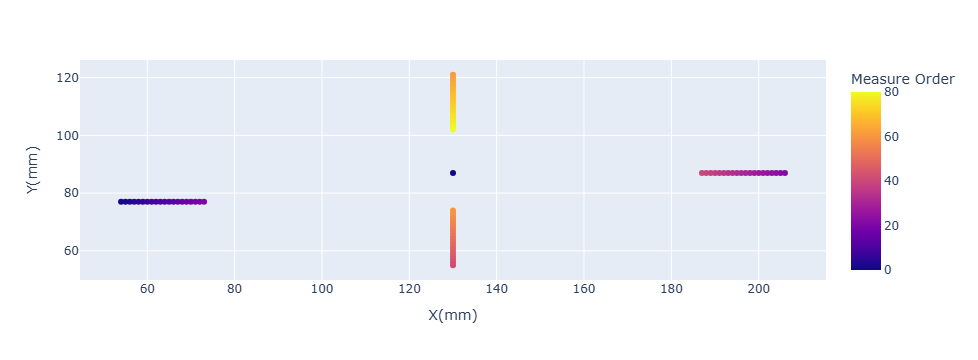

In [80]:
px.scatter(
    axo_parser.df.filter(pl.col('ID')=="215C96").with_columns(
        pl.Series(
            "Measure Order",
            list(range(81)),
        ),
    ),
    x='X(mm)',
    y='Y(mm)',
    color='Measure Order'
)

In [244]:
(plot_df
        .filter(pl.col('RMS(%)')<1)
        .with_columns(pl.col('Cross Area').cast(str))
).write_excel(work_dir / 'CGM' / 'summary_20250903.xlsx')

LCT-15-1098 + S-WB141


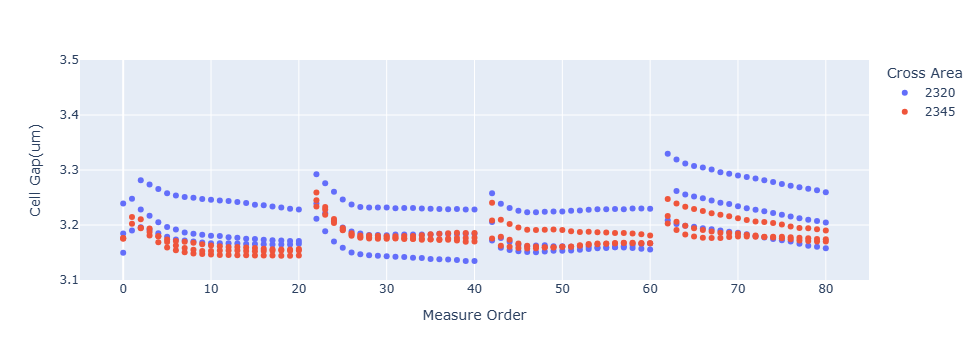

ZIX-7061XX + S-NP13


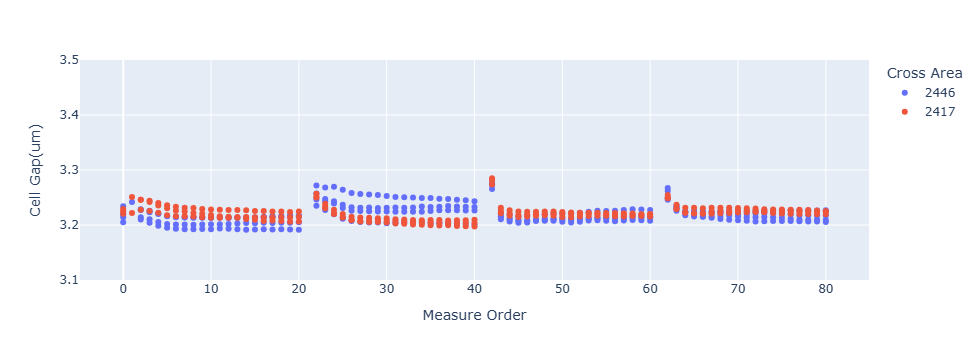

ZIX-7061XX + S-WB141


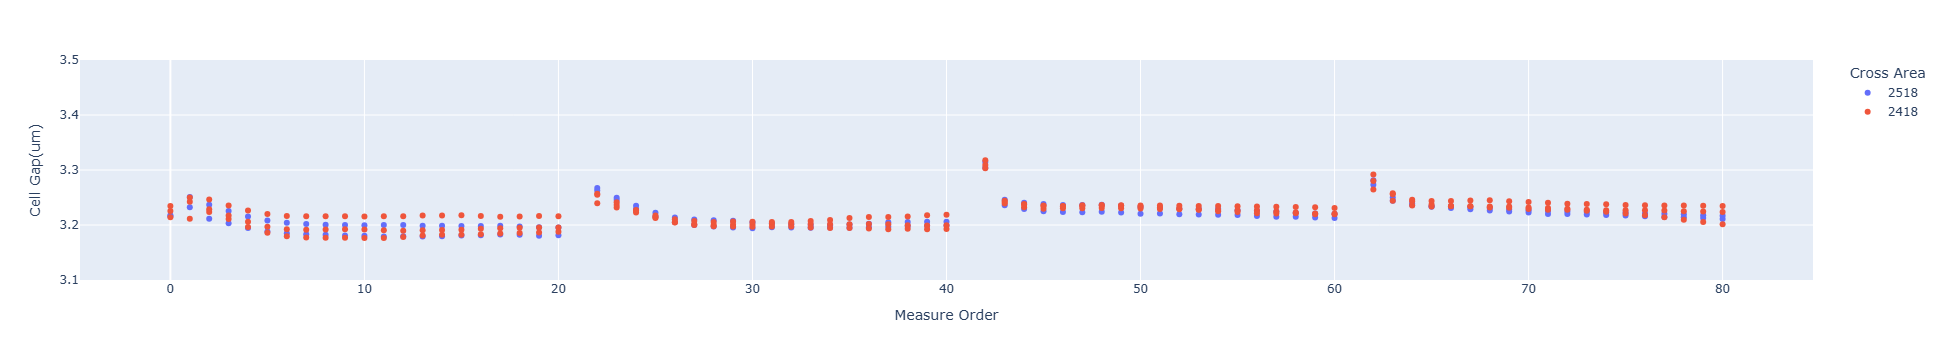

In [143]:
around_figs = SealAnalysis.Plot.around_gap(
    plot_df
        .filter(pl.col('RMS(%)')<1)
        .with_columns(pl.col('Cross Area').cast(str)),
    x='Measure Order',
    y='Cell Gap(um)',
    color='Cross Area',
)

ZIX-7061XX + S-WB141


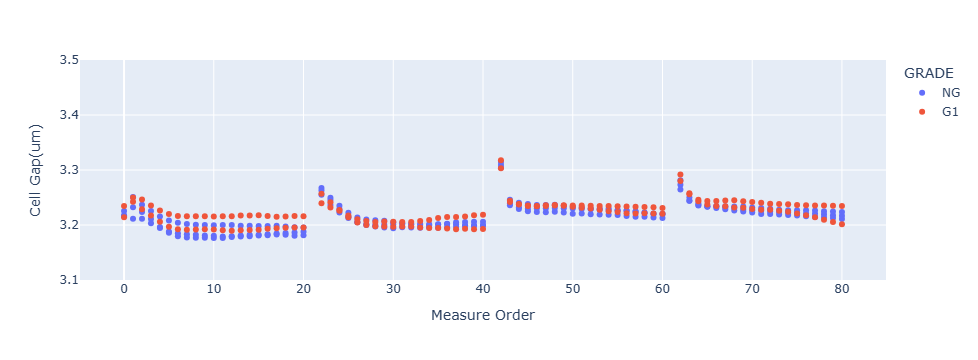

ZIX-7061XX + S-NP13


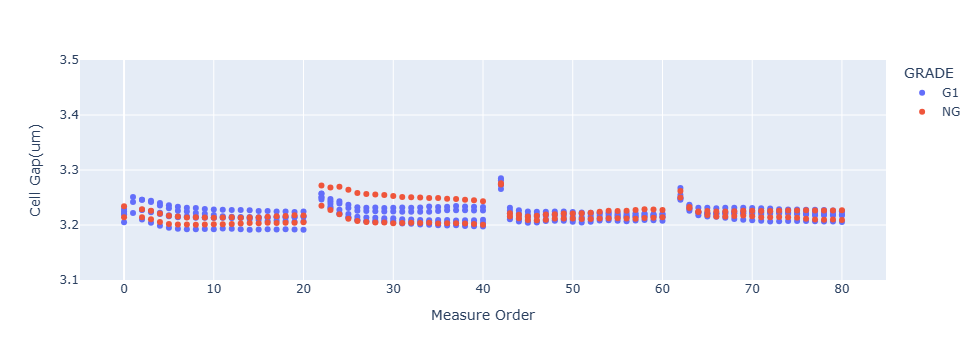

LCT-15-1098 + S-WB141


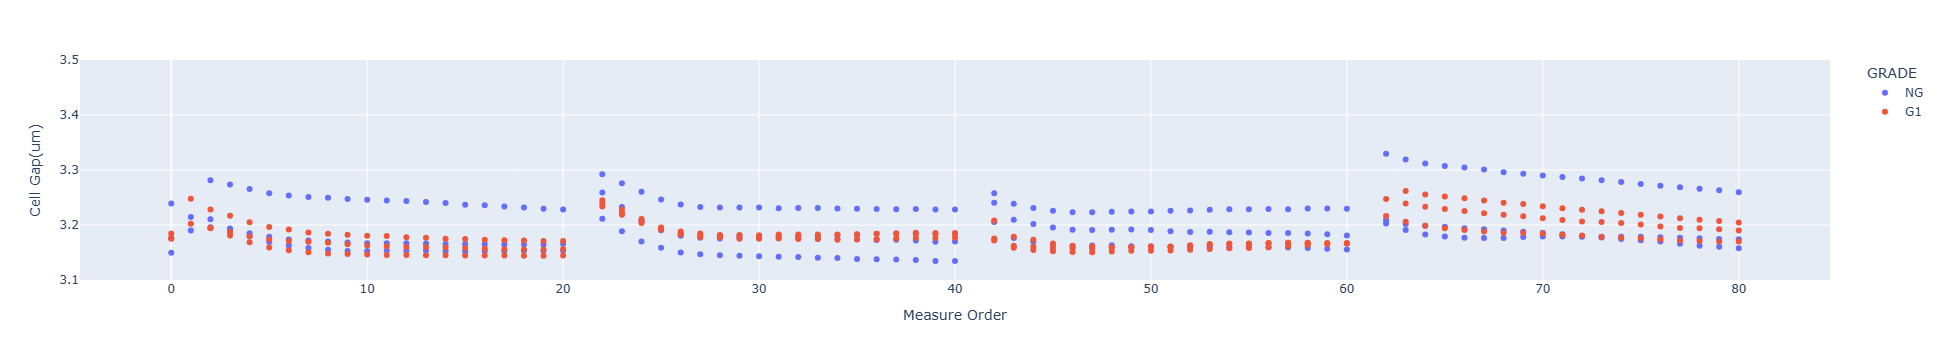

In [198]:
around_ct2_figs = SealAnalysis.Plot.around_gap(
    plot_df
        .filter(pl.col('RMS(%)')<1),
    x='Measure Order',
    y='Cell Gap(um)',
    color='GRADE',
)

In [23]:
df = axo_parser.around_gap()

In [24]:
df.head()

ID,Measure Order,Location,Cell Gap(um),Dist to Edge(mm),RMS(%)
str,i64,str,f64,i64,f64
"""210FB5""",0,"""center""",3.149687,0,0.248483
"""210FB5""",1,"""up""",3.189865,0,0.773582
"""210FB5""",2,"""up""",3.195987,1,0.239258
"""210FB5""",3,"""up""",3.191534,2,0.231841
"""210FB5""",4,"""up""",3.185135,3,0.253972


In [99]:
tmp_df = df.filter(
    pl.col('ID') == "210FB5",
    pl.col('Location') == 'right',
    (pl.col('Measure Order') % 20 > 4) | (pl.col('Measure Order') % 20 == 0),
)

In [108]:
tmp_df

ID,Location,Cell Gap(um),Dist to Edge(mm),Measure Order
str,str,f64,i64,i64
"""210FB5""","""right""",3.196793,4,65
"""210FB5""","""right""",3.194311,5,66
"""210FB5""","""right""",3.192342,6,67
"""210FB5""","""right""",3.189927,7,68
"""210FB5""","""right""",3.187541,8,69
…,…,…,…,…
"""210FB5""","""right""",3.169823,15,76
"""210FB5""","""right""",3.165964,16,77
"""210FB5""","""right""",3.162251,17,78


In [146]:
df

ID,Measure Order,Location,Cell Gap(um),Dist to Edge(mm),RMS(%)
str,i64,str,f64,i64,f64
"""210FB5""",0,"""center""",3.149687,0,0.248483
"""210FB5""",1,"""up""",3.189865,0,0.773582
"""210FB5""",2,"""up""",3.195987,1,0.239258
"""210FB5""",3,"""up""",3.191534,2,0.231841
"""210FB5""",4,"""up""",3.185135,3,0.253972
…,…,…,…,…,…
"""215C96""",76,"""right""",3.235699,15,0.237454
"""215C96""",77,"""right""",3.235278,16,0.236192
"""215C96""",78,"""right""",3.235292,17,0.238952


In [117]:
 df['ID'].unique()

ID
str
"""210FC4"""
"""215B64"""
"""210FB5"""
"""214BA4"""
"""215B54"""
…
"""214B75"""
"""214B85"""
"""215BA5"""


In [25]:
delta_gap = {
    "ID": [],
    "Location": [],
    "Class": [],
    "Delta(um)": [],
}

for glass_id in df['ID'].unique():
    delta_gap['ID'] += [glass_id] * 8
    delta_gap['Class'] += ['first - max', 'max - avg'] * 4
    for location in ['up', 'down', 'left', 'right']:
        tmp_df = df.filter(
            pl.col('ID') == glass_id,
            pl.col('Location') == location,
            # (pl.col('Measure Order') % 20 > 4) | (pl.col('Measure Order') % 20 == 0),
            pl.col('RMS(%)') < 1,
        )
        first = tmp_df[0,3]
        avg = tmp_df[-10:,3].mean()
        max_ = tmp_df[:,3].max()
        delta_gap['Location'] += [location] * 2
        delta_gap['Delta(um)'] += [first - max_, max_ - avg]

delta_gap_df = pl.DataFrame(delta_gap)

In [26]:
cond_df

Panel ID,DEFECT,GRADE,Sub ID,Type,Condition,DEFECT_DESC,CUT,Cross Area
str,str,str,str,str,str,str,str,i64
"""660L2AP50FN210FC4""","""PCDB7""","""G1""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2345
"""660L2AP50FN210FL5""","""PCDB7""","""G1""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2320
"""660L2AP50FN210FL4""","""PCDB7""","""G1""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2345
"""660L2AP50FN210FF4""","""PCDB7""","""NG""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2345
"""660L2AP50FN210FB5""","""PCDB7""","""NG""","""660L2AP50FN210""","""Thining - CT2""","""LCT-15-1098 + S-WB141""","""碎亮點""","""F""",2320
…,…,…,…,…,…,…,…,…
"""660L2AP50FN215BA5""","""PCDB7""","""G1""","""660L2AP50FN215""","""Thining - CT2""","""ZIX-7061XX + S-WB141""","""碎亮點""","""B""",2418
"""660L2AP50FN215C96""","""PCDB7""","""G1""","""660L2AP50FN215""","""Thining - CT2""","""ZIX-7061XX + S-WB141""","""碎亮點""","""C""",2418
"""660L2AP50FN215B54""","""PCDB7""","""NG""","""660L2AP50FN215""","""Thining - CT2""","""ZIX-7061XX + S-WB141""","""碎亮點""","""B""",2518


In [27]:
plot_df = delta_gap_df.join(
    cond_df.select('Panel ID', 'Condition', 'Cross Area').with_columns(
        pl.col('Panel ID').str.slice(-6).alias('ID')
    ),
    on='ID'
)

In [28]:
len(plot_df['Condition'].unique())

3

ZIX-7061XX + S-NP13
LCT-15-1098 + S-WB141
ZIX-7061XX + S-WB141


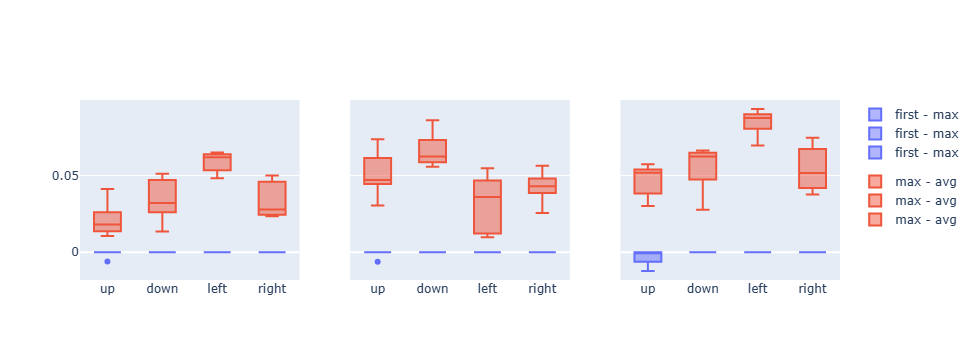

In [29]:
from plotly.subplots import make_subplots
fig = make_subplots(rows=1, cols=3, shared_yaxes=True)
for id_, cond in enumerate(plot_df['Condition'].unique()):
    print(cond)
    tmp_df = plot_df.filter(pl.col('Condition')==cond)
    sub_fig = px.box(
        tmp_df,
        x='Location',
        y='Delta(um)',
        color='Class',
    )
    for trace in sub_fig.data:
        fig.add_trace(trace, row=1, col=id_ + 1)

fig.show()

In [158]:
class SealAnalysis:
    class Table:
        @staticmethod
        def generate_delta_table(df: pl.DataFrame) -> pl.DataFrame:
            delta_gap = {
                "ID": [],
                "Location": [],
                "Class": [],
                "Delta(um)": [],
            }
            
            for glass_id in df['ID'].unique():
                delta_gap['ID'] += [glass_id] * 8
                delta_gap['Class'] += ['first - max', 'max - avg'] * 4
                for location in ['up', 'down', 'left', 'right']:
                    tmp_df = df.filter(
                        pl.col('ID') == glass_id,
                        pl.col('Location') == location,
                        # (pl.col('Measure Order') % 20 > 4) | (pl.col('Measure Order') % 20 == 0),
                        pl.col('RMS(%)') < 1,
                    )
                    first = tmp_df[0,3]
                    avg = tmp_df[-10:,3].mean()
                    max_ = tmp_df[:,3].max()
                    delta_gap['Location'] += [location] * 2
                    delta_gap['Delta(um)'] += [first - max_, max_ - avg]
            
            return pl.DataFrame(delta_gap)
    class Plot:
        @staticmethod
        def around_gap(df: pl.DataFrame, **params):
            figs = []
            for cond in plot_df['Condition'].unique():
                print(cond)
                figs.append(px.scatter(
                    df.filter(pl.col('Condition')==cond),
                    color_continuous_scale=px.colors.sequential.Jet,
                    # color_discrete_sequence=px.colors.sequential.Jet,
                    **params,
                ))
                figs[-1].update_layout(yaxis_range=(3.1, 3.5))
                figs[-1].show()
            return figs
        
        @staticmethod
        def around_delta(df: pl.DataFrame, **params):
            conds = df['Condition'].unique()
            fig = make_subplots(rows=1, cols=len(conds), shared_yaxes=True)
            for index, cond in enumerate(conds):
                print(cond)
                tmp_df = df.filter(pl.col('Condition')==cond)
                sub_fig = px.box(
                    tmp_df,
                    **params
                )
                for trace in sub_fig.data:
                    fig.add_trace(trace, row=1, col=index+1)
            return fig

In [155]:
delta_df = SealAnalysis.Table.generate_delta_table(df)

In [156]:
plot_df = delta_df.join(
    cond_df.select('Panel ID', 'Condition', 'Cross Area').with_columns(
        pl.col('Panel ID').str.slice(-6).alias('ID')
    ),
    on='ID'
)

In [109]:
plot_df

ID,Location,Class,Delta(um),Panel ID,Condition,Cross Area
str,str,str,f64,str,str,i64
"""210GL6""","""up""","""first - max""",0.0,"""660L2AP50FN210GL6""","""LCT-15-1098 + S-WB141""",2320
"""210GL6""","""up""","""max - avg""",0.044731,"""660L2AP50FN210GL6""","""LCT-15-1098 + S-WB141""",2320
"""210GL6""","""down""","""first - max""",0.0,"""660L2AP50FN210GL6""","""LCT-15-1098 + S-WB141""",2320
"""210GL6""","""down""","""max - avg""",0.062694,"""660L2AP50FN210GL6""","""LCT-15-1098 + S-WB141""",2320
"""210GL6""","""left""","""first - max""",0.0,"""660L2AP50FN210GL6""","""LCT-15-1098 + S-WB141""",2320
…,…,…,…,…,…,…
"""215BA4""","""down""","""max - avg""",0.066204,"""660L2AP50FN215BA4""","""ZIX-7061XX + S-WB141""",2518
"""215BA4""","""left""","""first - max""",0.0,"""660L2AP50FN215BA4""","""ZIX-7061XX + S-WB141""",2518
"""215BA4""","""left""","""max - avg""",0.088639,"""660L2AP50FN215BA4""","""ZIX-7061XX + S-WB141""",2518


In [84]:
with pl.Config(tbl_rows=100):
    print(plot_df
        .select('ID', 'Condition')
        .unique(maintain_order=True)
        # .to_series().to_list()
    )

shape: (11, 2)
┌────────┬───────────────────────┐
│ ID     ┆ Condition             │
│ ---    ┆ ---                   │
│ str    ┆ str                   │
╞════════╪═══════════════════════╡
│ 210GL6 ┆ LCT-15-1098 + S-WB141 │
│ 210FL4 ┆ LCT-15-1098 + S-WB141 │
│ 210FC4 ┆ LCT-15-1098 + S-WB141 │
│ 210FB5 ┆ LCT-15-1098 + S-WB141 │
│ 210FF4 ┆ LCT-15-1098 + S-WB141 │
│ 210FL5 ┆ LCT-15-1098 + S-WB141 │
│ 215BA5 ┆ ZIX-7061XX + S-WB141  │
│ 215B54 ┆ ZIX-7061XX + S-WB141  │
│ 215C96 ┆ ZIX-7061XX + S-WB141  │
│ 215B95 ┆ ZIX-7061XX + S-WB141  │
│ 215BA4 ┆ ZIX-7061XX + S-WB141  │
└────────┴───────────────────────┘


In [73]:
x_values

['210FB5',
 '215BA5',
 '210GL6',
 '210FF4',
 '215BA4',
 '210FC4',
 '215B95',
 '215C96',
 '215B54',
 '210FL5',
 '210FL4']

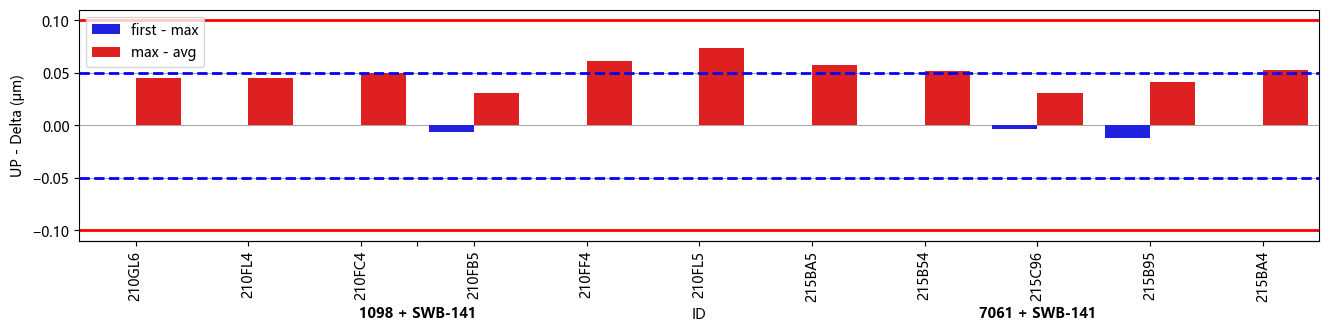

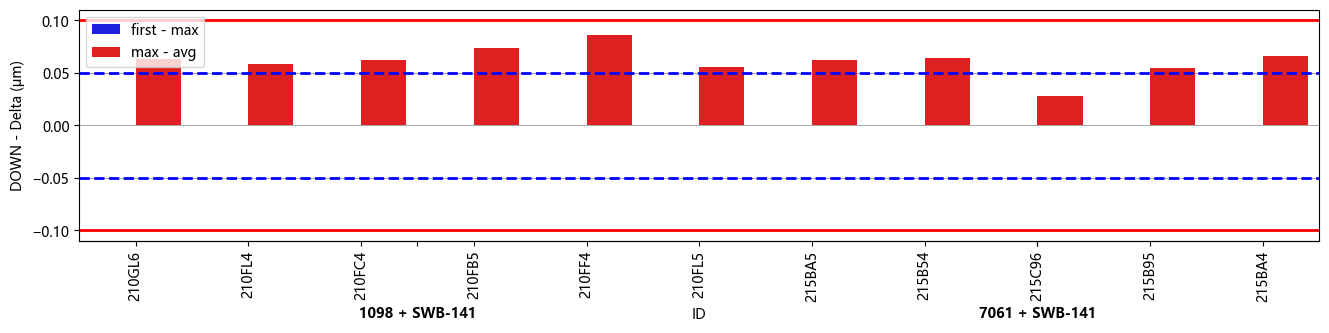

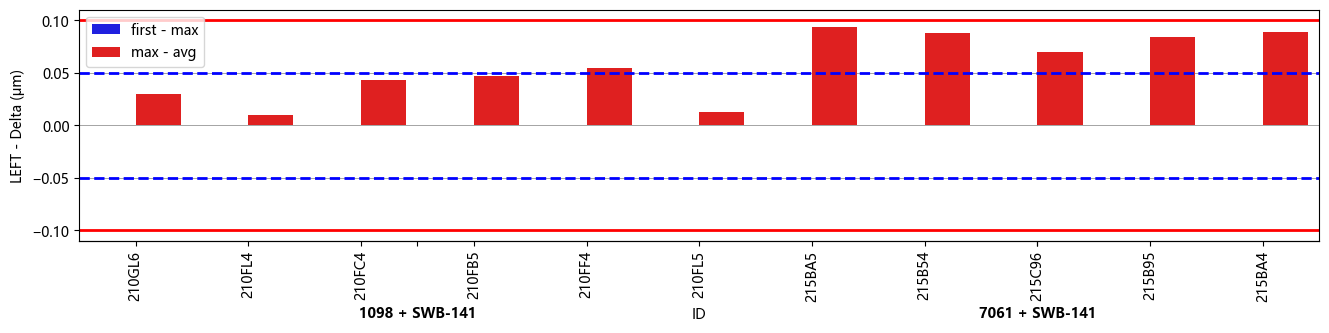

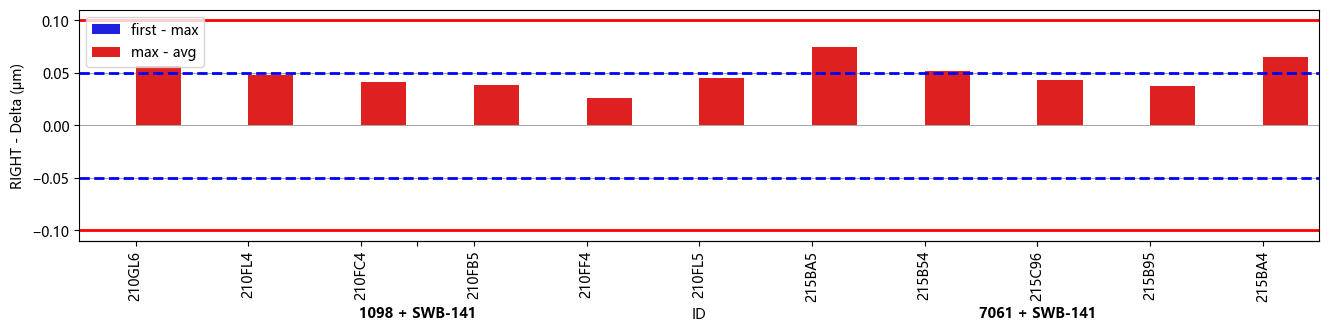

In [116]:
plot_df = plot_df.filter(pl.col('Condition').str.contains('S-WB141')).sort(by='Condition')
x_values = (plot_df
    .select('ID', 'Condition')
    .unique()
    .select('ID')
    .to_series().to_list()
)
x_position = np.arange(len(x_values))
color_palette = {
    "first - max": "blue",
    "max - avg": "red",
}

for location in plot_df.select('Location').unique(maintain_order=True).to_series():
    # print(location)
    fig, ax =  plt.subplots(figsize=(16,3))
    sns.barplot(
        data=plot_df.filter(pl.col('Location')==location),
        x="ID",
        y="Delta(um)",
        hue='Class',
        palette=color_palette,
        ax=ax,
    )
    ax.legend(loc="upper left")
    # ax.set_yticks(np.arange(-0.1,0.1,0.025))
    ax.grid(axis="y", linestyle="-", linewidth=0.5, color="gray", alpha=1)
    ax.set_axisbelow(True) # Put gridlines BEHIND the bars so it looks clean
    ax.tick_params(axis="x", rotation=90)
    ax.axhline(y= 0.10, color="red" , linestyle="-" , linewidth=2, label="US")
    ax.axhline(y= 0.05, color="blue", linestyle="--", linewidth=2, label="UC")
    ax.axhline(y=-0.10, color="red" , linestyle="-" , linewidth=2, label="DS")
    ax.axhline(y=-0.05, color="blue", linestyle="--", linewidth=2, label="DC")
    ax.set_ylabel(f"{location.upper()} - Delta (μm)")
    
    sec_ax = ax.secondary_xaxis(location=0) # 'buttom'
    sec_ax.set_xticks([2.5, 8]) # 0~5 "1098 + SWB-141", 6~10 "7061 + SWB-141"
    sec_ax.set_xticklabels(["\n\n\n""1098 + SWB-141", "\n\n\n""7061 + SWB-141"], weight="bold")
    
    plt.show()

ZIX-7061XX + S-NP13
ZIX-7061XX + S-WB141
LCT-15-1098 + S-WB141


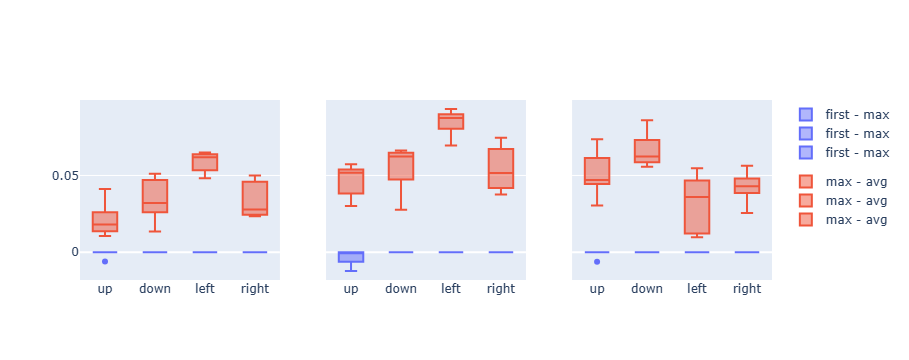

In [160]:
fig = SealAnalysis.Plot.around_delta(
    plot_df,
    x='Location',
    y='Delta(um)',
    color='Class',
)
fig.show()

In [118]:
root

WindowsPath('D:/Documents/Projects/innolux/data/T2 6628 BP 3500 A ZIX-7061 S-NP13 S-WB141')

In [119]:
seal_width = pl.read_excel(root / "T2_6628_薄板_seal_width_內衝.xlsx")

In [120]:
seal_width

條件,ID,位置,膠寬,內衝
str,str,str,i64,i64
"""LCT-15-1098 + S-WB141""","""210FF4""","""L""",539,0
"""LCT-15-1098 + S-WB141""","""210FB5""","""L""",482,0
"""LCT-15-1098 + S-WB141""","""210FL4""","""L""",517,0
"""LCT-15-1098 + S-WB141""","""210FL5""","""L""",477,75
"""LCT-15-1098 + S-WB141""","""210FC4""","""L""",545,0
…,…,…,…,…
"""ZIX-7061XX + S-WB141""","""215B95""","""D""",528,0
"""ZIX-7061XX + S-WB141""","""215BA4""","""D""",530,0
"""ZIX-7061XX + S-WB141""","""215B54""","""D""",528,0


<Axes: xlabel='條件', ylabel='內衝'>

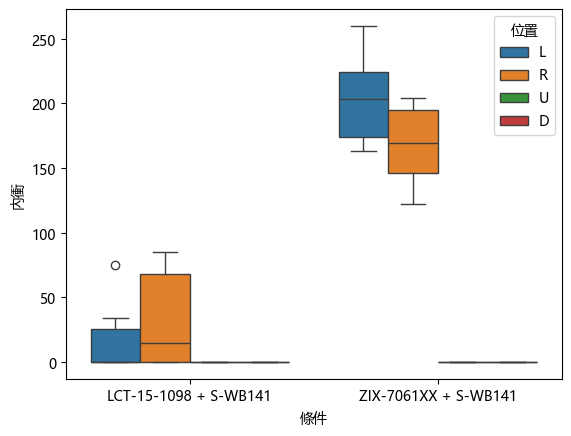

In [123]:
sns.boxplot(
    seal_width.filter(pl.col('條件').str.contains('S-WB141')),
    x='條件',
    y='內衝',
    hue='位置',
)

<Axes: xlabel='條件', ylabel='膠寬'>

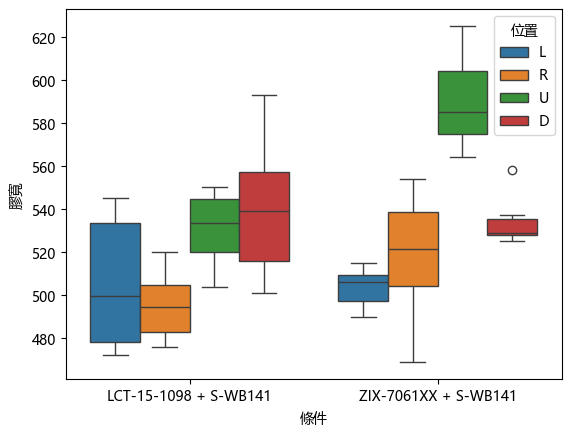

In [124]:
sns.boxplot(
    seal_width.filter(pl.col('條件').str.contains('S-WB141')),
    x='條件',
    y='膠寬',
    hue='位置',
)

In [ ]:
px.box(
    seal_width,
    x='條件',
    y='膠寬',
    color='位置',
)

In [172]:
seal_width

條件,ID,位置,膠寬,內衝
str,str,str,i64,i64
"""LCT-15-1098 + S-WB141""","""210FF4""","""L""",539,0
"""LCT-15-1098 + S-WB141""","""210FB5""","""L""",482,0
"""LCT-15-1098 + S-WB141""","""210FL4""","""L""",517,0
"""LCT-15-1098 + S-WB141""","""210FL5""","""L""",402,75
"""LCT-15-1098 + S-WB141""","""210FC4""","""L""",545,0
…,…,…,…,…
"""ZIX-7061XX + S-WB141""","""215B95""","""D""",528,0
"""ZIX-7061XX + S-WB141""","""215BA4""","""D""",530,0
"""ZIX-7061XX + S-WB141""","""215B54""","""D""",528,0


In [174]:
plot_df

ID,Location,Class,Delta(um),Panel ID,Condition,Cross Area
str,str,str,f64,str,str,i64
"""214B63""","""up""","""first - max""",0.0,"""660L2AP50FN214B63""","""ZIX-7061XX + S-NP13""",2446
"""214B63""","""up""","""max - avg""",0.013802,"""660L2AP50FN214B63""","""ZIX-7061XX + S-NP13""",2446
"""214B63""","""down""","""first - max""",0.0,"""660L2AP50FN214B63""","""ZIX-7061XX + S-NP13""",2446
"""214B63""","""down""","""max - avg""",0.024137,"""660L2AP50FN214B63""","""ZIX-7061XX + S-NP13""",2446
"""214B63""","""left""","""first - max""",0.0,"""660L2AP50FN214B63""","""ZIX-7061XX + S-NP13""",2446
…,…,…,…,…,…,…
"""214B53""","""down""","""max - avg""",0.013435,"""660L2AP50FN214B53""","""ZIX-7061XX + S-NP13""",2446
"""214B53""","""left""","""first - max""",0.0,"""660L2AP50FN214B53""","""ZIX-7061XX + S-NP13""",2446
"""214B53""","""left""","""max - avg""",0.051982,"""660L2AP50FN214B53""","""ZIX-7061XX + S-NP13""",2446


In [183]:
plot_df.join(seal_width, on='ID').filter(pl.col('Condition').str.contains('LCT-15-1098'))

ID,Location,Class,Delta(um),Panel ID,Condition,Cross Area,條件,位置,膠寬,內衝
str,str,str,f64,str,str,i64,str,str,i64,i64
"""210FL5""","""up""","""first - max""",0.0,"""660L2AP50FN210FL5""","""LCT-15-1098 + S-WB141""",2320,"""LCT-15-1098 + S-WB141""","""L""",402,75
"""210FL5""","""up""","""first - max""",0.0,"""660L2AP50FN210FL5""","""LCT-15-1098 + S-WB141""",2320,"""LCT-15-1098 + S-WB141""","""R""",420,81
"""210FL5""","""up""","""first - max""",0.0,"""660L2AP50FN210FL5""","""LCT-15-1098 + S-WB141""",2320,"""LCT-15-1098 + S-WB141""","""U""",524,0
"""210FL5""","""up""","""first - max""",0.0,"""660L2AP50FN210FL5""","""LCT-15-1098 + S-WB141""",2320,"""LCT-15-1098 + S-WB141""","""D""",530,0
"""210FL5""","""up""","""max - avg""",0.073591,"""660L2AP50FN210FL5""","""LCT-15-1098 + S-WB141""",2320,"""LCT-15-1098 + S-WB141""","""L""",402,75
…,…,…,…,…,…,…,…,…,…,…
"""210FC4""","""right""","""first - max""",0.0,"""660L2AP50FN210FC4""","""LCT-15-1098 + S-WB141""",2345,"""LCT-15-1098 + S-WB141""","""D""",560,0
"""210FC4""","""right""","""max - avg""",0.041397,"""660L2AP50FN210FC4""","""LCT-15-1098 + S-WB141""",2345,"""LCT-15-1098 + S-WB141""","""L""",545,0
"""210FC4""","""right""","""max - avg""",0.041397,"""660L2AP50FN210FC4""","""LCT-15-1098 + S-WB141""",2345,"""LCT-15-1098 + S-WB141""","""R""",506,0


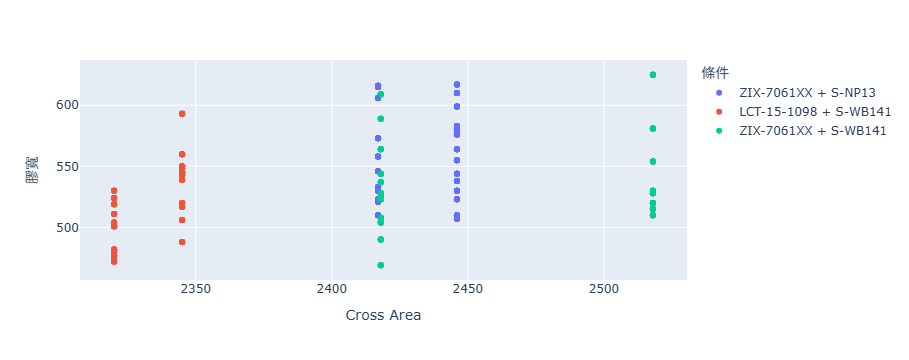

In [192]:
px.scatter(
    plot_df.join(seal_width, on='ID'),
    x='Cross Area',
    y='膠寬',
    color='條件'
)

## Weibull Distribution

In [240]:
LiquidCrystal.data['density']

Name
LCT-19-580     1.00970
ZIX-7061XX     1.00388
SLC19V33L00    1.01900
LCT-15-1098    0.99400
Name: density, dtype: float64

In [241]:
31.203 * 1.00388 / 0.99400

31.51314651911469